In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fifa_ranking-2024-06-20.csv to fifa_ranking-2024-06-20.csv
Saving results.csv to results.csv


In [ ]:
import os
os.listdir("/content/")


['.config', 'fifa_ranking-2024-06-20.csv', 'results.csv', 'sample_data']

In [ ]:
matches = pd.read_csv("/content/results.csv", parse_dates=["date"])
rankings = pd.read_csv("/content/fifa_ranking-2024-06-20.csv", parse_dates=["rank_date"])

print("Matches shape:", matches.shape)
print("Rankings shape:", rankings.shape)

Matches shape: (49287, 9)
Rankings shape: (67472, 8)


In [ ]:
matches.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [ ]:
rankings.head()

,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
0,140.0,Brunei Darussalam,BRU,2.0,0.0,140,AFC,1992-12-31
1,33.0,Portugal,POR,38.0,0.0,33,UEFA,1992-12-31
2,32.0,Zambia,ZAM,38.0,0.0,32,CAF,1992-12-31
3,31.0,Greece,GRE,38.0,0.0,31,UEFA,1992-12-31
4,30.0,Algeria,ALG,39.0,0.0,30,CAF,1992-12-31


In [ ]:
matches.columns = matches.columns.str.strip().str.lower().str.replace(" ", "_")
print(matches.isnull().sum())

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64


In [ ]:
before = len(matches)
matches = matches.dropna(subset=["home_score", "away_score"])
print(f"Dropped {before - len(matches)} rows — {len(matches)} remain")

Dropped 72 rows — 49215 remain


In [ ]:
matches["home_score"] = matches["home_score"].astype(int)
matches["away_score"] = matches["away_score"].astype(int)

matches = matches[matches["date"].dt.year >= 1993].reset_index(drop=True)
print("Shape after 1993 filter:", matches.shape)

Shape after 1993 filter: (30511, 9)


In [ ]:
before = len(matches)
matches = matches.drop_duplicates(subset=["date", "home_team", "away_team"])
print(f"Dropped {before - len(matches)} duplicates — {len(matches)} remain")

Dropped 0 duplicates — 30511 remain


In [ ]:
matches["goal_diff"] = matches["home_score"] - matches["away_score"]
matches["home_result"] = np.where(matches["goal_diff"] > 0, "W",
                         np.where(matches["goal_diff"] < 0, "L", "D"))

# Numeric label: 2=home win, 1=draw, 0=away win
matches["outcome"] = np.where(matches["goal_diff"] > 0, 2,
                     np.where(matches["goal_diff"] < 0, 0, 1))

print(matches["home_result"].value_counts())

home_result
W    14802
L     8588
D     7121
Name: count, dtype: int64


In [ ]:
tier_map = {
    "FIFA World Cup": 5,
    "UEFA Euro": 4,
    "Copa América": 4,
    "AFC Asian Cup": 4,
    "Africa Cup of Nations": 4,
    "CONCACAF Gold Cup": 3,
    "FIFA World Cup qualification": 3,
    "Friendly": 1,
}

matches["tournament_tier"] = matches["tournament"].map(
    lambda t: next((v for k, v in tier_map.items() if k in str(t)), 2)
)

print(matches["tournament_tier"].value_counts())

tournament_tier
1    10079
2     9561
5     7321
4     3550
Name: count, dtype: int64


In [ ]:
matches["home_advantage"]   = (~matches["neutral"]).astype(int)
matches["is_wc"]            = matches["tournament"].str.contains("FIFA World Cup$", na=False, regex=True).astype(int)
matches["is_wc_qualifier"]  = matches["tournament"].str.contains("qualification", case=False, na=False).astype(int)
matches["is_major_tourney"] = (matches["tournament_tier"] >= 4).astype(int)

print(matches[["is_wc","is_wc_qualifier","is_major_tourney","home_advantage"]].sum())

is_wc                 500
is_wc_qualifier     12035
is_major_tourney    10871
home_advantage      21899
dtype: int64


In [ ]:
rankings.columns = rankings.columns.str.strip().str.lower().str.replace(" ", "_")
print(rankings.isnull().sum())
print("\nDate range:", rankings["rank_date"].min(), "→", rankings["rank_date"].max())

rank               9
country_full       0
country_abrv       0
total_points       0
previous_points    0
rank_change        0
confederation      0
rank_date          0
dtype: int64

Date range: 1992-12-31 00:00:00 → 2024-06-20 00:00:00


In [ ]:
rankings = rankings[["rank_date", "country_full", "rank", "total_points"]]
rankings = rankings.sort_values("rank_date").reset_index(drop=True)
print(rankings.shape)
rankings.head()

(67472, 4)


,rank_date,country_full,rank,total_points
0,1992-12-31,Brunei Darussalam,140.0,2.0
1,1992-12-31,Solomon Islands,136.0,2.0
2,1992-12-31,Cabo Verde,135.0,3.0
3,1992-12-31,Mauritania,134.0,3.0
4,1992-12-31,Bangladesh,133.0,3.0


In [ ]:
match_teams = set(matches["home_team"].unique()) | set(matches["away_team"].unique())
rank_teams = set(rankings["country_full"].unique())

only_in_matches = match_teams - rank_teams
print(f"Teams in matches but NOT in rankings ({len(only_in_matches)}):")
print(sorted(only_in_matches))

Teams in matches but NOT in rankings (127):
['Abkhazia', 'Alderney', 'Ambazonia', 'Andalusia', 'Arameans Suryoye', 'Artsakh', 'Aymara', 'Barawa', 'Basque Country', 'Biafra', 'Bonaire', 'Brittany', 'Brunei', 'Canary Islands', 'Cape Verde', 'Cascadia', 'Catalonia', 'Chagos Islands', 'Chameria', 'Chechnya', 'Cilento', 'Corsica', 'County of Nice', 'Crimea', 'Curaçao', 'Czech Republic', 'DR Congo', 'Darfur', 'Donetsk PR', 'Délvidék', 'Elba Island', 'Ellan Vannin', 'Falkland Islands', 'Felvidék', 'Franconia', 'French Guiana', 'Frøya', 'Galicia', 'Gambia', 'Gotland', 'Gozo', 'Greenland', 'Guadeloupe', 'Guernsey', 'Găgăuzia', 'Hitra', 'Hmong', 'Iran', 'Iraqi Kurdistan', 'Isle of Man', 'Isle of Wight', 'Ivory Coast', 'Jersey', 'Kabylia', 'Kernow', 'Kiribati', 'Kyrgyzstan', 'Kárpátalja', 'Luhansk PR', 'Madrid', 'Mapuche', 'Marshall Islands', 'Martinique', 'Matabeleland', 'Maule Sur', 'Mayotte', 'Menorca', 'Micronesia', 'Monaco', 'North Korea', 'Northern Cyprus', 'Northern Mariana Islands', 'Occi

In [ ]:
rankings = rankings.sort_values("rank_date").drop_duplicates(
    subset=["rank_date", "country_full"]
).reset_index(drop=True)

matches = matches.sort_values("date").reset_index(drop=True)

In [ ]:
home_ranks = pd.merge_asof(
    matches[["date", "home_team"]].rename(columns={"home_team": "country_full"}),
    rankings,
    left_on="date",
    right_on="rank_date",
    by="country_full",
    direction="backward"
).rename(columns={"rank": "rank_home", "total_points": "points_home"})

matches["rank_home"]   = home_ranks["rank_home"]
matches["points_home"] = home_ranks["points_home"]

In [ ]:
away_ranks = pd.merge_asof(
    matches[["date", "away_team"]].rename(columns={"away_team": "country_full"}),
    rankings,
    left_on="date",
    right_on="rank_date",
    by="country_full",
    direction="backward"
).rename(columns={"rank": "rank_away", "total_points": "points_away"})

matches["rank_away"]   = away_ranks["rank_away"]
matches["points_away"] = away_ranks["points_away"]

In [ ]:
matches["rank_diff"]   = matches["rank_home"] - matches["rank_away"]
matches["points_diff"] = matches["points_home"] - matches["points_away"]

print(matches[["rank_home", "rank_away", "rank_diff", "points_diff"]].describe())

          rank_home     rank_away     rank_diff   points_diff
count  26794.000000  26750.000000  24297.000000  24303.000000
mean      80.808950     83.095065     -3.118410     13.370998
std       53.184935     53.708574     53.854166    266.893117
min        1.000000      1.000000   -209.000000  -1757.000000
25%       35.000000     38.000000    -36.000000   -101.000000
50%       75.000000     77.000000     -4.000000      6.000000
75%      119.000000    122.000000     29.000000    135.000000
max      211.000000    211.000000    210.000000   1596.000000


In [ ]:
only_in_matches = match_teams - rank_teams

# How many matches do these unmatched teams actually have?
unmatched_home = matches[matches["home_team"].isin(only_in_matches)]["home_team"].value_counts()
unmatched_away = matches[matches["away_team"].isin(only_in_matches)]["away_team"].value_counts()

unmatched_counts = (unmatched_home.add(unmatched_away, fill_value=0)
                    .sort_values(ascending=False))

print("Top 30 unmatched teams by match count:")
print(unmatched_counts.head(30))

Top 30 unmatched teams by match count:
United States                       556.0
South Korea                         518.0
Iran                                434.0
Ivory Coast                         375.0
Czech Republic                      358.0
DR Congo                            320.0
North Korea                         254.0
Saint Kitts and Nevis               206.0
Martinique                          199.0
Cape Verde                          191.0
Kyrgyzstan                          182.0
Saint Lucia                         171.0
Curaçao                             165.0
Gambia                              165.0
Guadeloupe                          162.0
Saint Vincent and the Grenadines    158.0
Taiwan                              139.0
French Guiana                       127.0
Jersey                              114.0
Guernsey                            104.0
Brunei                              102.0
Zanzibar                             90.0
United States Virgin Islands         

In [ ]:
name_map = {
    "United States":    "USA",
    "South Korea":      "Korea Republic",
    "Iran":             "IR Iran",
    "Ivory Coast":      "Côte d'Ivoire",
    "Czech Republic":   "Czechia",
    "DR Congo":         "Congo DR",
    "North Korea":      "Korea DPR",
    "Cape Verde":       "Cape Verde Islands",
    "Curaçao":          "Curaçao",
    "Kyrgyzstan":       "Kyrgyz Republic",
    "Taiwan":           "Chinese Taipei",
}

matches["home_team"] = matches["home_team"].replace(name_map)
matches["away_team"] = matches["away_team"].replace(name_map)

print("Done. Verifying fixes:")
for old, new in name_map.items():
    count = (matches["home_team"] == new).sum() + (matches["away_team"] == new).sum()
    print(f"  {old} → {new} : {count} matches")

Done. Verifying fixes:
  United States → USA : 556 matches
  South Korea → Korea Republic : 518 matches
  Iran → IR Iran : 434 matches
  Ivory Coast → Côte d'Ivoire : 375 matches
  Czech Republic → Czechia : 358 matches
  DR Congo → Congo DR : 320 matches
  North Korea → Korea DPR : 254 matches
  Cape Verde → Cape Verde Islands : 191 matches
  Curaçao → Curaçao : 165 matches
  Kyrgyzstan → Kyrgyz Republic : 182 matches
  Taiwan → Chinese Taipei : 139 matches


In [ ]:
match_teams_updated = set(matches["home_team"].unique()) | set(matches["away_team"].unique())
still_unmatched = match_teams_updated - rank_teams
print(f"Remaining unmatched: {len(still_unmatched)}")

Remaining unmatched: 118


In [ ]:
matches = matches.sort_values("date").reset_index(drop=True)

home_ranks = pd.merge_asof(
    matches[["date", "home_team"]].rename(columns={"home_team": "country_full"}),
    rankings,
    left_on="date",
    right_on="rank_date",
    by="country_full",
    direction="backward"
).rename(columns={"rank": "rank_home", "total_points": "points_home"})

matches["rank_home"]   = home_ranks["rank_home"]
matches["points_home"] = home_ranks["points_home"]

away_ranks = pd.merge_asof(
    matches[["date", "away_team"]].rename(columns={"away_team": "country_full"}),
    rankings,
    left_on="date",
    right_on="rank_date",
    by="country_full",
    direction="backward"
).rename(columns={"rank": "rank_away", "total_points": "points_away"})

matches["rank_away"]   = away_ranks["rank_away"]
matches["points_away"] = away_ranks["points_away"]

matches["rank_diff"]   = matches["rank_home"] - matches["rank_away"]
matches["points_diff"] = matches["points_home"] - matches["points_away"]

# Check null % after merge
null_pct = matches[["rank_home", "rank_away"]].isnull().mean() * 100
print(f"Null % — rank_home: {null_pct['rank_home']:.1f}%  rank_away: {null_pct['rank_away']:.1f}%")
print(f"Shape: {matches.shape}")

Null % — rank_home: 6.9%  rank_away: 7.5%
Shape: (30511, 23)


In [ ]:
home = matches[["date","home_team","home_score","away_score","outcome","tournament_tier"]].copy()
home.columns = ["date","team","goals_for","goals_against","outcome","tier"]
home["is_home"] = 1
home["win"]  = (home["outcome"] == 2).astype(int)
home["draw"] = (home["outcome"] == 1).astype(int)
home["pts"]  = home["win"] * 3 + home["draw"]

away = matches[["date","away_team","away_score","home_score","outcome","tournament_tier"]].copy()
away.columns = ["date","team","goals_for","goals_against","outcome","tier"]
away["is_home"] = 0
away["win"]  = (away["outcome"] == 0).astype(int)
away["draw"] = (away["outcome"] == 1).astype(int)
away["pts"]  = away["win"] * 3 + away["draw"]

long = pd.concat([home, away]).sort_values(["team","date"]).reset_index(drop=True)

print(long.shape)
long.head(10)

(61022, 10)


,date,team,goals_for,goals_against,outcome,tier,is_home,win,draw,pts
0,2012-09-25,Abkhazia,1,1,1,1,1,0,1,1
1,2012-10-21,Abkhazia,0,3,2,1,0,0,0,0
2,2014-06-01,Abkhazia,1,1,1,2,1,0,1,1
3,2014-06-02,Abkhazia,2,1,0,2,0,1,0,3
4,2014-06-04,Abkhazia,0,0,1,2,1,0,1,1
5,2014-06-05,Abkhazia,3,3,1,2,0,0,1,1
6,2014-06-07,Abkhazia,0,1,0,2,1,0,0,0
7,2015-05-05,Abkhazia,1,0,2,1,1,1,0,3
8,2015-05-14,Abkhazia,1,0,2,1,1,1,0,3
9,2016-05-21,Abkhazia,0,0,1,1,1,0,1,1


In [ ]:
for window in [5, 10]:
    for col in ["goals_for", "goals_against", "win", "draw", "pts"]:
        long[f"roll{window}_{col}"] = (
            long.groupby("team")[col]
            .transform(lambda x: x.shift(1).rolling(window, min_periods=2).mean())
        )

print("New columns added:")
print([c for c in long.columns if c.startswith("roll")])
print(long[long["team"] == "Brazil"].tail(10)[["date","team","goals_for","roll5_goals_for","roll10_goals_for","roll5_pts","roll10_pts"]])

New columns added:
['roll5_goals_for', 'roll5_goals_against', 'roll5_win', 'roll5_draw', 'roll5_pts', 'roll10_goals_for', 'roll10_goals_against', 'roll10_win', 'roll10_draw', 'roll10_pts']
           date    team  goals_for  roll5_goals_for  roll10_goals_for  \
7216 2025-06-05  Brazil          0              1.8               1.3   
7217 2025-06-10  Brazil          1              1.0               1.2   
7218 2025-09-04  Brazil          3              1.0               1.3   
7219 2025-09-09  Brazil          0              1.4               1.5   
7220 2025-10-10  Brazil          5              1.0               1.5   
7221 2025-10-14  Brazil          2              1.8               1.8   
7222 2025-11-15  Brazil          2              2.2               1.6   
7223 2025-11-18  Brazil          1              2.4               1.7   
7224 2026-03-26  Brazil          1              2.0               1.7   
7225 2026-03-31  Brazil          3              2.2               1.6   

      r

In [ ]:
roll_cols = [c for c in long.columns if c.startswith("roll")]

home_long = long[long["is_home"] == 1][["date","team"] + roll_cols].copy()
home_long.columns = ["date","home_team"] + [f"home_{c}" for c in roll_cols]

away_long = long[long["is_home"] == 0][["date","team"] + roll_cols].copy()
away_long.columns = ["date","away_team"] + [f"away_{c}" for c in roll_cols]

matches = matches.merge(home_long, on=["date","home_team"], how="left")
matches = matches.merge(away_long, on=["date","away_team"], how="left")

print("Shape after rolling merge:", matches.shape)
print("Sample rolling columns:", [c for c in matches.columns if "roll" in c][:6])


Shape after rolling merge: (30542, 43)
Sample rolling columns: ['home_roll5_goals_for', 'home_roll5_goals_against', 'home_roll5_win', 'home_roll5_draw', 'home_roll5_pts', 'home_roll10_goals_for']


In [ ]:
dupes = matches[matches.duplicated(subset=["date","home_team","away_team"], keep=False)]
print(f"Duplicate rows: {len(dupes)}")
print(dupes[["date","home_team","away_team"]].head(10))

Duplicate rows: 56
           date  home_team   away_team
317  1993-05-16     Kuwait       Macau
318  1993-05-16     Kuwait       Macau
320  1993-05-16  Korea DPR       Macau
321  1993-05-16  Korea DPR       Macau
1497 1995-03-25      Nepal  Bangladesh
1498 1995-03-25      Nepal  Bangladesh
1499 1995-03-25   Pakistan  Bangladesh
1500 1995-03-25   Pakistan  Bangladesh
3249 1997-05-11   Mongolia    China PR
3250 1997-05-11   Mongolia    China PR


In [ ]:
matches = matches.drop_duplicates(subset=["date","home_team","away_team"]).reset_index(drop=True)
print("Shape after dedup:", matches.shape)

Shape after dedup: (30511, 43)


In [ ]:
for window in [5, 10]:
    for col in ["goals_for", "goals_against", "win", "pts"]:
        h = f"home_roll{window}_{col}"
        a = f"away_roll{window}_{col}"
        matches[f"delta_{window}_{col}"] = matches[h] - matches[a]

print("Delta columns added:")
print([c for c in matches.columns if c.startswith("delta_")])
print("\nSample:")
print(matches[["home_team","away_team"] + [c for c in matches.columns if c.startswith("delta_")]].head(5))

Delta columns added:
['delta_5_goals_for', 'delta_5_goals_against', 'delta_5_win', 'delta_5_pts', 'delta_10_goals_for', 'delta_10_goals_against', 'delta_10_win', 'delta_10_pts']

Sample:
      home_team     away_team  delta_5_goals_for  delta_5_goals_against  \
0         Ghana          Mali                NaN                    NaN   
1         Gabon  Burkina Faso                NaN                    NaN   
2        Kuwait       Lebanon                NaN                    NaN   
3  Burkina Faso          Mali                NaN                    NaN   
4         Gabon         Ghana                NaN                    NaN   

   delta_5_win  delta_5_pts  delta_10_goals_for  delta_10_goals_against  \
0          NaN          NaN                 NaN                     NaN   
1          NaN          NaN                 NaN                     NaN   
2          NaN          NaN                 NaN                     NaN   
3          NaN          NaN                 NaN               

In [ ]:
matches['year'] = matches['date'].dt.year
# Check null rate for delta columns
null_pct = matches[["delta_5_goals_for", "delta_10_goals_for"]].isnull().mean() * 100
print(f"Null % — delta_5: {null_pct['delta_5_goals_for']:.1f}%  delta_10: {null_pct['delta_10_goals_for']:.1f}%")

# Confirm nulls are concentrated in early years
null_by_year = matches[matches["delta_5_goals_for"].isnull()].groupby("year").size()
print("\nNull delta_5 counts by year:")
print(null_by_year)

Null % — delta_5: 1.6%  delta_10: 1.6%

Null delta_5 counts by year:
year
1993    249
1994     32
1995     20
1996      3
1997     13
1998     15
1999     16
2000      3
2001      8
2002      1
2003      9
2004      2
2005      6
2006     14
2007      5
2008      7
2009      3
2010      7
2011      4
2012     13
2013      2
2014     11
2015      9
2016     11
2017      1
2018     10
2019      5
2022      8
2023      4
2025      2
dtype: int64


In [ ]:
matches.to_csv("features_engineered.csv", index=False)
print("Saved features_engineered.csv")
print("Final shape:", matches.shape)
print("\nAll columns:")
print(list(matches.columns))


Saved features_engineered.csv
Final shape: (30511, 52)

All columns:
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'goal_diff', 'home_result', 'outcome', 'tournament_tier', 'home_advantage', 'is_wc', 'is_wc_qualifier', 'is_major_tourney', 'rank_home', 'points_home', 'rank_away', 'points_away', 'rank_diff', 'points_diff', 'home_roll5_goals_for', 'home_roll5_goals_against', 'home_roll5_win', 'home_roll5_draw', 'home_roll5_pts', 'home_roll10_goals_for', 'home_roll10_goals_against', 'home_roll10_win', 'home_roll10_draw', 'home_roll10_pts', 'away_roll5_goals_for', 'away_roll5_goals_against', 'away_roll5_win', 'away_roll5_draw', 'away_roll5_pts', 'away_roll10_goals_for', 'away_roll10_goals_against', 'away_roll10_win', 'away_roll10_draw', 'away_roll10_pts', 'delta_5_goals_for', 'delta_5_goals_against', 'delta_5_win', 'delta_5_pts', 'delta_10_goals_for', 'delta_10_goals_against', 'delta_10_win', 'delta_10_pts', 'year']


In [ ]:
recent = matches[matches["year"] >= 2010].copy()

home_s = recent.groupby("home_team").agg(
    home_matches=("date","count"),
    home_goals_for=("home_score","sum"),
    home_goals_against=("away_score","sum"),
    home_wins=("outcome", lambda x: (x==2).sum()),
    home_draws=("outcome", lambda x: (x==1).sum()),
).reset_index().rename(columns={"home_team":"team"})

away_s = recent.groupby("away_team").agg(
    away_matches=("date","count"),
    away_goals_for=("away_score","sum"),
    away_goals_against=("home_score","sum"),
    away_wins=("outcome", lambda x: (x==0).sum()),
    away_draws=("outcome", lambda x: (x==1).sum()),
).reset_index().rename(columns={"away_team":"team"})

summary = pd.merge(home_s, away_s, on="team", how="outer").fillna(0)
summary["total_matches"]  = summary["home_matches"] + summary["away_matches"]
summary["total_goals_for"] = summary["home_goals_for"] + summary["away_goals_for"]
summary["total_goals_against"] = summary["home_goals_against"] + summary["away_goals_against"]
summary["total_wins"]   = summary["home_wins"] + summary["away_wins"]
summary["total_draws"]  = summary["home_draws"] + summary["away_draws"]
summary["total_losses"] = summary["total_matches"] - summary["total_wins"] - summary["total_draws"]
summary["win_rate"]     = (summary["total_wins"] / summary["total_matches"]).round(3)
summary["goals_per_game"] = (summary["total_goals_for"] / summary["total_matches"]).round(3)
summary["goals_conceded_per_game"] = (summary["total_goals_against"] / summary["total_matches"]).round(3)
summary["goal_diff_per_game"] = ((summary["total_goals_for"] - summary["total_goals_against"]) / summary["total_matches"]).round(3)

summary = summary.sort_values("total_matches", ascending=False).reset_index(drop=True)
summary.to_csv("team_summaries.csv", index=False)
print("Saved team_summaries.csv")
print(summary.head(10)[["team","total_matches","win_rate","goals_per_game","goal_diff_per_game"]])

Saved team_summaries.csv
             team  total_matches  win_rate  goals_per_game  goal_diff_per_game
0          Mexico          280.0     0.539           1.593               0.643
1             USA          252.0     0.528           1.778               0.722
2           Qatar          246.0     0.447           1.549               0.402
3            Iraq          233.0     0.425           1.193               0.210
4          Panama          230.0     0.422           1.387               0.178
5      Costa Rica          230.0     0.374           1.296               0.109
6          Jordan          229.0     0.419           1.459               0.419
7         Bahrain          226.0     0.389           1.243               0.173
8  Korea Republic          226.0     0.540           1.659               0.677
9    Saudi Arabia          225.0     0.413           1.320               0.249


In [ ]:
summary[summary["team"]=="France"]

,team,home_matches,home_goals_for,home_goals_against,home_wins,home_draws,away_matches,away_goals_for,away_goals_against,away_wins,...,total_matches,total_goals_for,total_goals_against,total_wins,total_draws,total_losses,win_rate,goals_per_game,goals_conceded_per_game,goal_diff_per_game
13,France,122.0,273.0,93.0,83.0,21.0,89.0,135.0,84.0,48.0,...,211.0,408.0,177.0,131.0,44.0,36.0,0.621,1.934,0.839,1.095


In [ ]:
print(matches.shape)
print(matches.columns.tolist())

(30511, 52)
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'goal_diff', 'home_result', 'outcome', 'tournament_tier', 'home_advantage', 'is_wc', 'is_wc_qualifier', 'is_major_tourney', 'rank_home', 'points_home', 'rank_away', 'points_away', 'rank_diff', 'points_diff', 'home_roll5_goals_for', 'home_roll5_goals_against', 'home_roll5_win', 'home_roll5_draw', 'home_roll5_pts', 'home_roll10_goals_for', 'home_roll10_goals_against', 'home_roll10_win', 'home_roll10_draw', 'home_roll10_pts', 'away_roll5_goals_for', 'away_roll5_goals_against', 'away_roll5_win', 'away_roll5_draw', 'away_roll5_pts', 'away_roll10_goals_for', 'away_roll10_goals_against', 'away_roll10_win', 'away_roll10_draw', 'away_roll10_pts', 'delta_5_goals_for', 'delta_5_goals_against', 'delta_5_win', 'delta_5_pts', 'delta_10_goals_for', 'delta_10_goals_against', 'delta_10_win', 'delta_10_pts', 'year']


In [ ]:
feature_cols = [
    # FIFA rankings
    "rank_home", "rank_away", "rank_diff", "points_home", "points_away", "points_diff",
    # Recent form - home team
    "home_roll5_goals_for", "home_roll5_goals_against", "home_roll5_win", "home_roll5_pts",
    "home_roll10_goals_for", "home_roll10_goals_against", "home_roll10_win", "home_roll10_pts",
    # Recent form - away team
    "away_roll5_goals_for", "away_roll5_goals_against", "away_roll5_win", "away_roll5_pts",
    "away_roll10_goals_for", "away_roll10_goals_against", "away_roll10_win", "away_roll10_pts",
    # Form deltas
    "delta_5_goals_for", "delta_5_goals_against", "delta_5_win", "delta_5_pts",
    "delta_10_goals_for", "delta_10_goals_against", "delta_10_win", "delta_10_pts",
    # Context
    "home_advantage", "tournament_tier", "is_wc", "is_wc_qualifier", "is_major_tourney"
]

target = "outcome"  # 2=home win, 1=draw, 0=away win

print(f"Features: {len(feature_cols)}")
print(f"Target distribution:\n{matches[target].value_counts()}")

Features: 35
Target distribution:
outcome
2    14802
0     8588
1     7121
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Drop rows missing any feature
model_df = matches[feature_cols + [target, "date", "home_team", "away_team"]].dropna().reset_index(drop=True)
print(f"Rows after dropping nulls: {len(model_df)}")

# Time-based split — train on pre-2022, test on 2022 onwards
train = model_df[model_df["date"] < "2022-01-01"]
test  = model_df[model_df["date"] >= "2022-01-01"]

X_train = train[feature_cols]
y_train = train[target]
X_test  = test[feature_cols]
y_test  = test[target]

print(f"Train size: {len(train)} | Test size: {len(test)}")
print(f"Test date range: {test['date'].min().date()} → {test['date'].max().date()}")

Rows after dropping nulls: 27018
Train size: 23086 | Test size: 3932
Test date range: 2022-01-01 → 2026-03-31


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete")
print(f"X_train mean (first 3 features): {X_train_scaled.mean(axis=0)[:3].round(4)}")
print(f"X_train std  (first 3 features): {X_train_scaled.std(axis=0)[:3].round(4)}")

Scaling complete
X_train mean (first 3 features): [ 0.  0. -0.]
X_train std  (first 3 features): [1. 1. 1.]


In [ ]:
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=["Away Win","Draw","Home Win"]))

Logistic Regression Results:
Accuracy: 0.5468

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.53      0.67      0.59      1152
        Draw       0.27      0.24      0.26       928
    Home Win       0.70      0.62      0.66      1852

    accuracy                           0.55      3932
   macro avg       0.50      0.51      0.50      3932
weighted avg       0.55      0.55      0.54      3932



In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=["Away Win","Draw","Home Win"]))

Random Forest Results:
Accuracy: 0.5862

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.57      0.59      0.58      1152
        Draw       0.31      0.04      0.07       928
    Home Win       0.61      0.86      0.71      1852

    accuracy                           0.59      3932
   macro avg       0.49      0.50      0.45      3932
weighted avg       0.53      0.59      0.52      3932



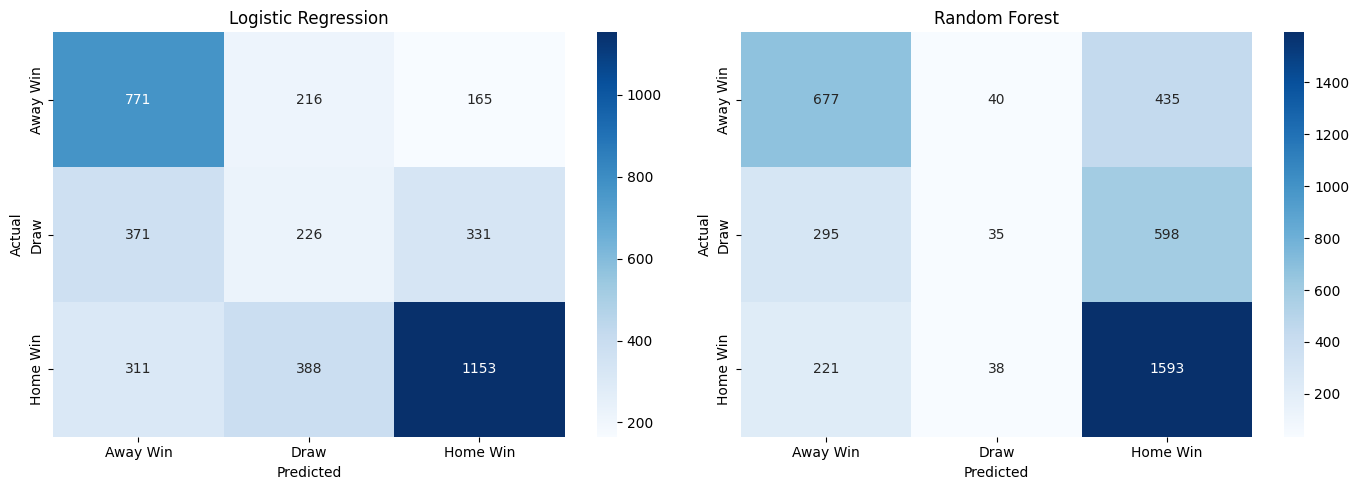

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ["Away Win", "Draw", "Home Win"]

for ax, preds, title in zip(axes,
                             [lr_preds, rf_preds],
                             ["Logistic Regression", "Random Forest"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_375/3080398609.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x="importance", y="feature", palette="viridis")


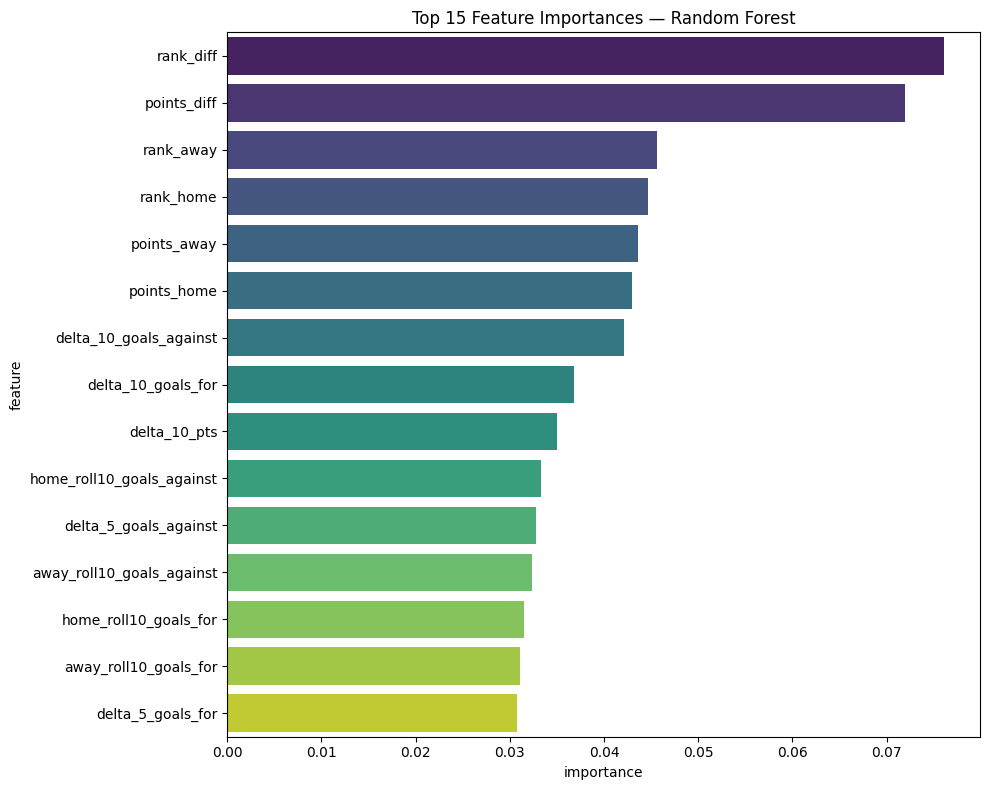

                      feature  importance
0                   rank_diff    0.076112
1                 points_diff    0.071936
2                   rank_away    0.045630
3                   rank_home    0.044662
4                 points_away    0.043576
5                 points_home    0.043007
6      delta_10_goals_against    0.042114
7          delta_10_goals_for    0.036857
8                delta_10_pts    0.035037
9   home_roll10_goals_against    0.033257
10      delta_5_goals_against    0.032757
11  away_roll10_goals_against    0.032337
12      home_roll10_goals_for    0.031519
13      away_roll10_goals_for    0.031130
14          delta_5_goals_for    0.030810


In [ ]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x="importance", y="feature", palette="viridis")
plt.title("Top 15 Feature Importances — Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(importance_df.head(15).to_string())

In [ ]:
import pickle

with open("lr_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("Saved: lr_model.pkl, rf_model.pkl, scaler.pkl, feature_cols.pkl")

Saved: lr_model.pkl, rf_model.pkl, scaler.pkl, feature_cols.pkl


## Phase 2 — Model Selection Decision

**Logistic Regression** selected for match probability outputs in Phase 4 Monte Carlo Simulator.
- More balanced predictions across all three outcomes (home win / draw / away win)
- Better F1 scores on draws (0.26 vs 0.07) and away wins (0.59 vs 0.58)
- Probability outputs are well-calibrated, suitable for simulation sampling

**Random Forest** retained for feature importance analysis and interpretation.
- Higher overall accuracy (58.6% vs 54.7%)
- Confirms FIFA ranking gap and form deltas as strongest predictive signals
- Referenced in Tableau dashboard and project writeup

Overall accuracy benchmark: 58.6% (RF) — comparable to industry standard for football prediction models.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import shutil
import os

# Create project folder in Drive
save_path = "/content/drive/MyDrive/FIFA_WC_2026"
os.makedirs(save_path, exist_ok=True)

# Files to save
files_to_save = [
    "features_engineered.csv",
    "team_summaries.csv",
    "lr_model.pkl",
    "rf_model.pkl",
    "scaler.pkl",
    "feature_cols.pkl",
    "confusion_matrices.png",
    "feature_importance.png"
]

for file in files_to_save:
    shutil.copy(f"/content/{file}", f"{save_path}/{file}")
    print(f"✓ Saved {file}")

print(f"\nAll files saved to Google Drive: {save_path}")

✓ Saved features_engineered.csv
✓ Saved team_summaries.csv
✓ Saved lr_model.pkl
✓ Saved rf_model.pkl
✓ Saved scaler.pkl
✓ Saved feature_cols.pkl
✓ Saved confusion_matrices.png
✓ Saved feature_importance.png

All files saved to Google Drive: /content/drive/MyDrive/FIFA_WC_2026


## Phase 3 — Poisson Score Prediction Model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

# Load feature matrix
matches = pd.read_csv("/content/drive/MyDrive/FIFA_WC_2026/features_engineered.csv",
                      parse_dates=["date"])

# Load scaler and feature cols from Phase 2
with open("/content/drive/MyDrive/FIFA_WC_2026/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("/content/drive/MyDrive/FIFA_WC_2026/feature_cols.pkl", "rb") as f:
    feature_cols = pickle.load(f)

print("Matches shape:", matches.shape)
print("Features loaded:", len(feature_cols))

Matches shape: (30511, 52)
Features loaded: 35


In [ ]:
# Filter to post 2010 for more relevant modern football patterns
model_data = matches[matches["date"].dt.year >= 2010].copy()

# Build long format - one row per team per match
home = model_data[["date", "home_team", "away_team", "home_score", "tournament_tier"]].copy()
home.columns = ["date", "team", "opponent", "goals", "tier"]
home["is_home"] = 1

away = model_data[["date", "away_team", "home_team", "away_score", "tournament_tier"]].copy()
away.columns = ["date", "team", "opponent", "goals", "tier"]
away["is_home"] = 0

goal_data = pd.concat([home, away]).sort_values("date").reset_index(drop=True)

print("Goal data shape:", goal_data.shape)
print("\nGoal distribution:")
print(goal_data["goals"].value_counts().sort_index())

Goal data shape: (31264, 6)

Goal distribution:
goals
0     10319
1      9721
2      5981
3      2754
4      1302
5       553
6       302
7       137
8        84
9        38
10       36
11       10
12        5
13        5
14        5
15        3
16        2
17        4
18        1
19        1
20        1
Name: count, dtype: int64


In [ ]:
match_20 = matches[(matches["home_score"] == 20) | (matches["away_score"] == 20)]
print(match_20[["date", "home_team", "away_team", "home_score", "away_score", "tournament"]])

            date   home_team      away_team  home_score  away_score  \
3249  1997-05-13  Kazakhstan           Guam          20           1   
5473  2000-02-14      Kuwait         Bhutan          20           0   
8629  2003-06-30        Sark  Isle of Wight           0          20   
19053 2014-06-01      Darfur        Padania           0          20   

                        tournament  
3249              East Asian Games  
5473   AFC Asian Cup qualification  
8629                  Island Games  
19053    CONIFA World Football Cup  


In [ ]:
# Overall average goals per match
avg_goals = goal_data["goals"].mean()
print(f"Average goals per team per match: {avg_goals:.4f}")

# Goals scored and conceded per team
attack = goal_data.groupby("team")["goals"].mean().rename("avg_scored")
defense = goal_data.groupby(["team", "opponent"])

# Compute goals conceded per team
conceded = goal_data.groupby("opponent")["goals"].mean().rename("avg_conceded")

# Combine into team ratings
team_ratings = pd.DataFrame({
    "attack_strength": attack / avg_goals,
    "defense_strength": conceded / avg_goals
}).reset_index()

team_ratings.columns = ["team", "attack_strength", "defense_strength"]
team_ratings = team_ratings.sort_values("attack_strength", ascending=False).reset_index(drop=True)

print(f"\nTop 10 teams by attack strength:")
print(team_ratings.head(10).to_string())

Average goals per team per match: 1.3616

Top 10 teams by attack strength:
                 team  attack_strength  defense_strength
0         Elba Island         3.672070          0.000000
1            Provence         2.937656          1.560630
2         Isle of Man         2.937656          0.897617
3           Yorkshire         2.832739          1.154079
4  Parishes of Jersey         2.692851          0.979219
5           Occitania         2.622907          0.594526
6              Kernow         2.570449          0.367207
7            Cascadia         2.413074          1.468828
8              Surrey         2.203242          0.734414
9     Northern Cyprus         2.203242          0.587531


In [ ]:
# Filter to teams that appear in the rankings dataset
import pickle

# Load rankings to get valid FIFA teams
rankings = pd.read_csv("/content/fifa_ranking-2024-06-20.csv", parse_dates=["rank_date"])
fifa_teams = set(rankings["country_full"].unique())

# Also add the mapped names we fixed in Phase 1
name_map_values = ["USA", "Korea Republic", "IR Iran", "Côte d'Ivoire",
                   "Czechia", "Congo DR", "Korea DPR", "Cape Verde Islands",
                   "Curaçao", "Kyrgyz Republic", "Chinese Taipei"]

fifa_teams.update(name_map_values)

# Filter goal data
goal_data = goal_data[
    goal_data["team"].isin(fifa_teams) &
    goal_data["opponent"].isin(fifa_teams)
].reset_index(drop=True)

print(f"Goal data shape after FIFA filter: {goal_data.shape}")
print(f"Unique teams remaining: {goal_data['team'].nunique()}")

Goal data shape after FIFA filter: (28402, 6)
Unique teams remaining: 204


In [ ]:
# Recalculate average goals on clean data
avg_goals = goal_data["goals"].mean()
print(f"Average goals per team per match: {avg_goals:.4f}")

# Attack strength — how prolific a team is relative to average
attack = goal_data.groupby("team")["goals"].mean().rename("avg_scored")

# Defense strength — how many goals a team concedes relative to average
conceded = goal_data.groupby("opponent")["goals"].mean().rename("avg_conceded")

# Combine into team ratings
team_ratings = pd.concat([attack / avg_goals, conceded / avg_goals], axis=1).reset_index()
team_ratings.columns = ["team", "attack_strength", "defense_strength"]
team_ratings = team_ratings.sort_values("attack_strength", ascending=False).reset_index(drop=True)

print(f"\nTop 15 teams by attack strength:")
print(team_ratings.head(15).to_string())

print(f"\nBottom 10 teams by attack strength:")
print(team_ratings.tail(10).to_string())

Average goals per team per match: 1.3158

Top 15 teams by attack strength:
                  team  attack_strength  defense_strength
0              Germany         1.769717          0.832382
1                Spain         1.762479          0.571810
2              Belgium         1.711018          0.686846
3          Netherlands         1.690615          0.752246
4        New Caledonia         1.685220          0.848117
5             Portugal         1.616865          0.625883
6                Japan         1.597691          0.695823
7               Brazil         1.574288          0.517525
8              England         1.542917          0.553770
9            Argentina         1.516434          0.560189
10  Dominican Republic         1.492532          0.988917
11             IR Iran         1.491400          0.498495
12              France         1.469576          0.637536
13             Algeria         1.468274          0.688378
14           Australia         1.391259          0.7558

In [ ]:
from scipy.stats import poisson

def predict_scoreline(home_team, away_team, team_ratings, avg_goals, home_advantage=1.1):
    """
    Predict scoreline probabilities using Poisson model.
    home_advantage factor of 1.1 = 10% boost for home team.
    """
    home = team_ratings[team_ratings["team"] == home_team]
    away = team_ratings[team_ratings["team"] == away_team]

    if home.empty or away.empty:
        print(f"Team not found in ratings")
        return None

    # Expected goals
    home_xg = (home["attack_strength"].values[0] *
                away["defense_strength"].values[0] *
                avg_goals * home_advantage)

    away_xg = (away["attack_strength"].values[0] *
                home["defense_strength"].values[0] *
                avg_goals)

    print(f"{home_team} xG: {home_xg:.3f}")
    print(f"{away_team} xG: {away_xg:.3f}")

    # Probability matrix for scorelines 0-6
    max_goals = 7
    home_probs = [poisson.pmf(i, home_xg) for i in range(max_goals)]
    away_probs = [poisson.pmf(i, away_xg) for i in range(max_goals)]

    score_matrix = np.outer(home_probs, away_probs)

    # Win/draw/loss probabilities
    home_win = np.sum(np.tril(score_matrix, -1))
    draw     = np.sum(np.diag(score_matrix))
    away_win = np.sum(np.triu(score_matrix, 1))

    print(f"\nHome Win: {home_win:.1%}  Draw: {draw:.1%}  Away Win: {away_win:.1%}")

    return score_matrix, home_xg, away_xg

# Test with a classic matchup
score_matrix, home_xg, away_xg = predict_scoreline(
    "Brazil", "Argentina", team_ratings, avg_goals
)

Brazil xG: 1.276
Argentina xG: 1.033

Home Win: 41.9%  Draw: 28.0%  Away Win: 30.0%


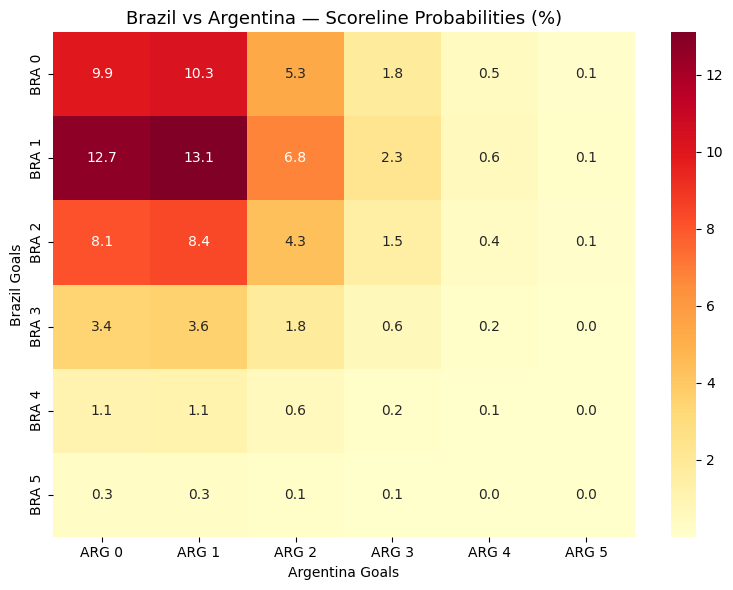

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    score_matrix[:6, :6] * 100,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    xticklabels=[f"ARG {i}" for i in range(6)],
    yticklabels=[f"BRA {i}" for i in range(6)],
    ax=ax
)

ax.set_title("Brazil vs Argentina — Scoreline Probabilities (%)", fontsize=13)
ax.set_xlabel("Argentina Goals")
ax.set_ylabel("Brazil Goals")

plt.tight_layout()
plt.savefig("scoreline_matrix_bra_arg.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
def predict_scoreline_silent(home_team, away_team, team_ratings, avg_goals, home_advantage=1.1):
    home = team_ratings[team_ratings["team"] == home_team]
    away = team_ratings[team_ratings["team"] == away_team]

    if home.empty or away.empty:
        return None

    home_xg = (home["attack_strength"].values[0] *
                away["defense_strength"].values[0] *
                avg_goals * home_advantage)

    away_xg = (away["attack_strength"].values[0] *
                home["defense_strength"].values[0] *
                avg_goals)

    max_goals = 7
    home_probs = [poisson.pmf(i, home_xg) for i in range(max_goals)]
    away_probs = [poisson.pmf(i, away_xg) for i in range(max_goals)]

    score_matrix = np.outer(home_probs, away_probs)

    home_win = np.sum(np.tril(score_matrix, -1))
    draw     = np.sum(np.diag(score_matrix))
    away_win = np.sum(np.triu(score_matrix, 1))

    return score_matrix, home_xg, away_xg, home_win, draw, away_win

In [ ]:
# Rebuild validation set from matches directly
rated_teams_set = set(team_ratings["team"].unique())

validation = matches[
    (matches["date"].dt.year >= 2022) &
    (matches["home_team"].isin(rated_teams_set)) &
    (matches["away_team"].isin(rated_teams_set))
].copy().reset_index(drop=True)

print(f"Validation matches: {len(validation)}")
print(validation[["date","home_team","away_team","outcome"]].head(5))

Validation matches: 4016
        date   home_team     away_team  outcome
0 2022-01-01    Thailand     Indonesia        1
1 2022-01-02       Gabon  Burkina Faso        0
2 2022-01-02       Sudan      Zimbabwe        1
3 2022-01-03      Rwanda        Guinea        2
4 2022-01-04  Mauritania         Gabon        1


In [ ]:
results = []

# Filter validation to only include teams present in team_ratings
rated_teams_set = set(team_ratings["team"].unique())

# Rebuild validation directly from matches, ensuring home_team, away_team, and outcome are present
# Also apply the date filter (2022 onwards, as per `test` definition) and team ratings filter
initial_validation_count = len(matches[matches["date"].dt.year >= 2022])

validation = matches[
    (matches["date"].dt.year >= 2022) &
    matches["home_team"].isin(rated_teams_set) &
    matches["away_team"].isin(rated_teams_set)
][["date", "home_team", "away_team", "outcome"]].copy().reset_index(drop=True)

print(f"Validation set (2022 onwards) reduced from {initial_validation_count} to {len(validation)} matches due to missing team ratings.")

for _, row in validation.iterrows():
    try:
        output = predict_scoreline_silent(
            row["home_team"], row["away_team"],
            team_ratings, avg_goals,
            home_advantage=1.1
        )
        if output is None:
            # This should ideally not happen after filtering, but keep as safeguard
            print(f"Warning: predict_scoreline_silent returned None for {row['home_team']} vs {row['away_team']} even after filtering.")
            continue

        score_matrix, home_xg, away_xg, home_win_prob, draw_prob, away_win_prob = output

        probs = [away_win_prob, draw_prob, home_win_prob]
        predicted = np.argmax(probs)

        results.append({
            "actual": row["outcome"],
            "predicted": predicted,
            "home_win_prob": home_win_prob,
            "draw_prob": draw_prob,
            "away_win_prob": away_win_prob,
            "home_xg": home_xg,
            "away_xg": away_xg
        })
    except Exception as e:
        print(f"Error processing match {row['home_team']} vs {row['away_team']}: {e}")
        continue

results_df = pd.DataFrame(results)

if results_df.empty:
    print("Error: No matches were successfully evaluated after filtering. Check team_ratings and validation data.")
else:
    accuracy = (results_df["actual"] == results_df["predicted"]).mean()
    print(f"Poisson Model Accuracy: {accuracy:.4f}")
    print(f"Matches evaluated: {len(results_df)}")

Validation set (2022 onwards) reduced from 4414 to 4016 matches due to missing team ratings.
Poisson Model Accuracy: 0.5904
Matches evaluated: 4016


In [ ]:
import pickle

# Save team ratings
team_ratings.to_csv("team_ratings.csv", index=False)

# Save the silent prediction function and key variables
with open("poisson_data.pkl", "wb") as f:
    pickle.dump({
        "team_ratings": team_ratings,
        "avg_goals": avg_goals,
        "fifa_teams": fifa_teams
    }, f)

# Copy to Drive
import shutil
shutil.copy("team_ratings.csv", "/content/drive/MyDrive/FIFA_WC_2026/team_ratings.csv")
shutil.copy("poisson_data.pkl", "/content/drive/MyDrive/FIFA_WC_2026/poisson_data.pkl")
shutil.copy("scoreline_matrix_bra_arg.png", "/content/drive/MyDrive/FIFA_WC_2026/scoreline_matrix_bra_arg.png")

print("✓ Saved team_ratings.csv")
print("✓ Saved poisson_data.pkl")
print("✓ Saved scoreline_matrix_bra_arg.png")
print("✓ All Phase 3 outputs saved to Drive")

✓ Saved team_ratings.csv
✓ Saved poisson_data.pkl
✓ Saved scoreline_matrix_bra_arg.png
✓ All Phase 3 outputs saved to Drive


In [ ]:
# Full confirmed WC 2026 team list using exact names from our dataset where possible
wc_teams = [
    # Group A
    "Mexico", "South Africa", "Korea Republic", "Czechia",
    # Group B
    "Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland",
    # Group C
    "Brazil", "Morocco", "Haiti", "Scotland",
    # Group D
    "USA", "Paraguay", "Australia", "Türkiye",
    # Group E
    "Germany", "Curaçao", "Côte d'Ivoire", "Ecuador",
    # Group F
    "Netherlands", "Japan", "Sweden", "Tunisia",
    # Group G
    "Belgium", "Egypt", "IR Iran", "New Zealand",
    # Group H
    "Spain", "Cabo Verde", "Saudi Arabia", "Uruguay",
    # Group I
    "France", "Senegal", "Norway", "Iraq",
    # Group J
    "Argentina", "Algeria", "Austria", "Jordan",
    # Group K
    "Portugal", "Uzbekistan", "Colombia", "Congo DR",
    # Group L
    "England", "Croatia", "Ghana", "Panama"
]

print(f"Total WC teams: {len(wc_teams)}")

# Check which ones are missing from our ratings
rated_teams = set(team_ratings["team"].unique())
missing = [t for t in wc_teams if t not in rated_teams]
present = [t for t in wc_teams if t in rated_teams]

print(f"\nTeams WITH ratings: {len(present)}")
print(f"Teams MISSING ratings: {len(missing)}")
print(f"\nMissing teams: {missing}")

Total WC teams: 48

Teams WITH ratings: 46
Teams MISSING ratings: 2

Missing teams: ['Türkiye', 'Cabo Verde']


In [ ]:
# Fix name variants in team_ratings
team_ratings["team"] = team_ratings["team"].replace({
    "Turkey":             "Türkiye",
    "Cape Verde Islands": "Cabo Verde"
})

# Also fix in goal_data for consistency
goal_data["team"]     = goal_data["team"].replace({
    "Turkey":             "Türkiye",
    "Cape Verde Islands": "Cabo Verde"
})
goal_data["opponent"] = goal_data["opponent"].replace({
    "Turkey":             "Türkiye",
    "Cape Verde Islands": "Cabo Verde"
})

# Verify all 48 are now present
rated_teams = set(team_ratings["team"].unique())
missing = [t for t in wc_teams if t not in rated_teams]
print(f"Missing teams after fix: {missing}")
print(f"All 48 teams accounted for: {len(missing) == 0}")

Missing teams after fix: []
All 48 teams accounted for: True


In [ ]:
# Save updated team ratings
team_ratings.to_csv("team_ratings.csv", index=False)
shutil.copy("team_ratings.csv", "/content/drive/MyDrive/FIFA_WC_2026/team_ratings.csv")
print("✓ Updated team_ratings.csv saved to Drive")

✓ Updated team_ratings.csv saved to Drive


PHASE 4 - MONTE CARLO SIMULATION

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

# Load saved data
matches = pd.read_csv("/content/drive/MyDrive/FIFA_WC_2026/features_engineered.csv", parse_dates=["date"])
team_ratings = pd.read_csv("/content/drive/MyDrive/FIFA_WC_2026/team_ratings.csv")

with open("/content/drive/MyDrive/FIFA_WC_2026/poisson_data.pkl", "rb") as f:
    poisson_data = pickle.load(f)

avg_goals = poisson_data["avg_goals"]

print("avg_goals:", avg_goals)
print("team_ratings shape:", team_ratings.shape)
print("matches shape:", matches.shape)

avg_goals: 1.3157876205900993
team_ratings shape: (204, 3)
matches shape: (30511, 52)


In [ ]:
groups = {
    "A": ["Mexico", "South Africa", "Korea Republic", "Czechia"],
    "B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["USA", "Paraguay", "Australia", "Türkiye"],
    "E": ["Germany", "Curaçao", "Côte d'Ivoire", "Ecuador"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "IR Iran", "New Zealand"],
    "H": ["Spain", "Cabo Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Norway", "Iraq"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "Uzbekistan", "Colombia", "Congo DR"],
    "L": ["England", "Croatia", "Ghana", "Panama"]
}

# Verify all 48 teams are in ratings
rated = set(team_ratings["team"].unique())
for group, teams in groups.items():
    for team in teams:
        if team not in rated:
            print(f"WARNING: {team} (Group {group}) missing from ratings")

print("All teams verified ✓")

All teams verified ✓


In [ ]:
from scipy.stats import poisson

def simulate_match(home_team, away_team, team_ratings, avg_goals, home_advantage=1.1, neutral=False):
    """
    Simulate a single match using Poisson model.
    Returns (home_goals, away_goals).
    neutral=True removes home advantage (used for knockout stage).
    """
    home = team_ratings[team_ratings["team"] == home_team]
    away = team_ratings[team_ratings["team"] == away_team]

    # Fallback to average if team not found
    avg_attack  = team_ratings["attack_strength"].mean()
    avg_defense = team_ratings["defense_strength"].mean()

    home_att = home["attack_strength"].values[0]  if not home.empty else avg_attack
    home_def = home["defense_strength"].values[0] if not home.empty else avg_defense
    away_att = away["attack_strength"].values[0]  if not away.empty else avg_attack
    away_def = away["defense_strength"].values[0] if not away.empty else avg_defense

    ha = 1.0 if neutral else home_advantage

    home_xg = home_att * away_def * avg_goals * ha
    away_xg = away_att * home_def * avg_goals

    home_goals = np.random.poisson(home_xg)
    away_goals = np.random.poisson(away_xg)

    return home_goals, away_goals


def simulate_match_winner(home_team, away_team, team_ratings, avg_goals, neutral=True):
    """
    Simulate a knockout match — returns the winner.
    Draws go to penalty shootout (50/50).
    """
    home_goals, away_goals = simulate_match(
        home_team, away_team, team_ratings, avg_goals, neutral=neutral
    )

    if home_goals > away_goals:
        return home_team
    elif away_goals > home_goals:
        return away_team
    else:
        # Penalty shootout — 50/50
        return np.random.choice([home_team, away_team])


# Quick sanity check
np.random.seed(42)
for _ in range(5):
    hg, ag = simulate_match("Brazil", "Argentina", team_ratings, avg_goals, neutral=True)
    print(f"Brazil {hg} - {ag} Argentina")

Brazil 2 - 1 Argentina
Brazil 0 - 0 Argentina
Brazil 3 - 2 Argentina
Brazil 0 - 0 Argentina
Brazil 0 - 1 Argentina


In [ ]:
def simulate_group_stage(groups, team_ratings, avg_goals):
    """
    Simulate full group stage. Returns:
      - group_standings: dict of group -> sorted list of (team, points, gd, gf)
      - all_third_place: list of third place teams with their stats for best-of-8 selection
    """
    group_standings = {}
    all_third_place = []

    for group_name, teams in groups.items():
        # Initialise stats
        stats = {t: {"pts": 0, "gd": 0, "gf": 0} for t in teams}

        # Round robin — every pair plays once
        for i in range(len(teams)):
            for j in range(i+1, len(teams)):
                home, away = teams[i], teams[j]
                hg, ag = simulate_match(home, away, team_ratings, avg_goals, neutral=False)

                stats[home]["gf"] += hg
                stats[away]["gf"] += ag
                stats[home]["gd"] += hg - ag
                stats[away]["gd"] += ag - hg

                if hg > ag:
                    stats[home]["pts"] += 3
                elif ag > hg:
                    stats[away]["pts"] += 3
                else:
                    stats[home]["pts"] += 1
                    stats[away]["pts"] += 1

        # Sort by points, then goal difference, then goals scored
        standings = sorted(
            teams,
            key=lambda t: (stats[t]["pts"], stats[t]["gd"], stats[t]["gf"]),
            reverse=True
        )

        group_standings[group_name] = [
            (t, stats[t]["pts"], stats[t]["gd"], stats[t]["gf"])
            for t in standings
        ]

        # Collect third place team
        third = group_standings[group_name][2]
        all_third_place.append((group_name, third[0], third[1], third[2], third[3]))

    # Select 8 best third place teams
    all_third_place.sort(key=lambda x: (x[2], x[3], x[4]), reverse=True)
    best_third = [t[1] for t in all_third_place[:8]]

    return group_standings, best_third


# Test single run
np.random.seed(42)
standings, best_third = simulate_group_stage(groups, team_ratings, avg_goals)

print("Sample group standings:")
for group in ["A", "C", "J"]:
    print(f"\nGroup {group}:")
    for rank, (team, pts, gd, gf) in enumerate(standings[group], 1):
        print(f"  {rank}. {team:30} Pts:{pts}  GD:{gd}  GF:{gf}")

print(f"\nBest 8 third-place teams:")
for t in best_third:
    print(f"  {t}")

Sample group standings:

Group A:
  1. Mexico                         Pts:7  GD:2  GF:5
  2. Korea Republic                 Pts:5  GD:1  GF:1
  3. South Africa                   Pts:2  GD:-1  GF:2
  4. Czechia                        Pts:1  GD:-2  GF:3

Group C:
  1. Morocco                        Pts:6  GD:-3  GF:4
  2. Brazil                         Pts:5  GD:6  GF:7
  3. Haiti                          Pts:4  GD:2  GF:5
  4. Scotland                       Pts:1  GD:-5  GF:2

Group J:
  1. Algeria                        Pts:9  GD:7  GF:11
  2. Austria                        Pts:4  GD:1  GF:5
  3. Argentina                      Pts:3  GD:0  GF:5
  4. Jordan                         Pts:1  GD:-8  GF:2

Best 8 third-place teams:
  Haiti
  France
  Sweden
  Egypt
  Croatia
  Türkiye
  Canada
  Argentina


In [ ]:
def simulate_knockout(group_standings, best_third, team_ratings, avg_goals):
    """
    Simulate full knockout stage from Round of 32 to Final.
    Returns the tournament winner.
    """
    # Extract group winners and runners up
    w = {g: group_standings[g][0][0] for g in group_standings}  # winners
    r = {g: group_standings[g][1][0] for g in group_standings}  # runners up

    # Round of 32 — exactly 16 matchups (32 teams)
    # 12 group winners + 12 runners up + 8 best third place = 32
    r32_matchups = [
        (w["A"], best_third[0]),
        (w["B"], best_third[1]),
        (w["C"], best_third[2]),
        (w["D"], best_third[3]),
        (w["E"], best_third[4]),
        (w["F"], best_third[5]),
        (w["G"], best_third[6]),
        (w["H"], best_third[7]),
        (w["A"], r["B"]),
        (w["C"], r["D"]),
        (w["E"], r["F"]),
        (w["G"], r["H"]),
        (w["I"], r["J"]),
        (w["K"], r["L"]),
        (w["J"], r["I"]),
        (w["L"], r["K"]),
    ]

    print(f"R32 matchups: {len(r32_matchups)} — teams: {len(r32_matchups)*2}")

    def play_round(matchups):
        return [simulate_match_winner(h, a, team_ratings, avg_goals, neutral=True)
                for h, a in matchups]

    # Round of 32 → 16 winners
    r16_teams = play_round(r32_matchups)
    print(f"R16 teams: {len(r16_teams)}")

    # Round of 16 → 8 winners
    r16_matchups = [(r16_teams[i], r16_teams[i+1]) for i in range(0, 16, 2)]
    qf_teams = play_round(r16_matchups)
    print(f"QF teams: {len(qf_teams)}")

    # Quarter Finals → 4 winners
    qf_matchups = [(qf_teams[i], qf_teams[i+1]) for i in range(0, 8, 2)]
    sf_teams = play_round(qf_matchups)
    print(f"SF teams: {len(sf_teams)}")

    # Semi Finals → 2 winners
    sf_matchups = [(sf_teams[i], sf_teams[i+1]) for i in range(0, 4, 2)]
    final_teams = play_round(sf_matchups)
    print(f"Final teams: {final_teams}")

    # Final
    winner = simulate_match_winner(final_teams[0], final_teams[1],
                                   team_ratings, avg_goals, neutral=True)
    return winner


# Test single run
np.random.seed(42)
standings, best_third = simulate_group_stage(groups, team_ratings, avg_goals)
champion = simulate_knockout(standings, best_third, team_ratings, avg_goals)
print(f"\nTournament winner: {champion}")

R32 matchups: 16 — teams: 32
R16 teams: 16
QF teams: 8
SF teams: 4
Final teams: ['Switzerland', np.str_('Congo DR')]

Tournament winner: Switzerland


In [ ]:
def simulate_group_stage_fast(groups, team_ratings, avg_goals):
    """
    Vectorized group stage simulation using numpy.
    """
    tr = team_ratings.set_index("team")
    avg_att = tr["attack_strength"].mean()
    avg_def = tr["defense_strength"].mean()

    group_standings = {}
    all_third_place = []

    for group_name, teams in groups.items():
        pts = {t: 0 for t in teams}
        gd  = {t: 0 for t in teams}
        gf  = {t: 0 for t in teams}

        for i in range(len(teams)):
            for j in range(i+1, len(teams)):
                home, away = teams[i], teams[j]

                h_att = tr.loc[home, "attack_strength"]  if home in tr.index else avg_att
                h_def = tr.loc[home, "defense_strength"] if home in tr.index else avg_def
                a_att = tr.loc[away, "attack_strength"]  if away in tr.index else avg_att
                a_def = tr.loc[away, "defense_strength"] if away in tr.index else avg_def

                hg = np.random.poisson(h_att * a_def * avg_goals * 1.1)
                ag = np.random.poisson(a_att * h_def * avg_goals)

                gf[home] += hg; gf[away] += ag
                gd[home] += hg - ag; gd[away] += ag - hg

                if hg > ag:   pts[home] += 3
                elif ag > hg: pts[away] += 3
                else:         pts[home] += 1; pts[away] += 1

        standings = sorted(teams,
                           key=lambda t: (pts[t], gd[t], gf[t]),
                           reverse=True)

        group_standings[group_name] = [(t, pts[t], gd[t], gf[t]) for t in standings]
        third = group_standings[group_name][2]
        all_third_place.append((group_name, third[0], third[1], third[2], third[3]))

    all_third_place.sort(key=lambda x: (x[2], x[3], x[4]), reverse=True)
    best_third = [t[1] for t in all_third_place[:8]]

    return group_standings, best_third


# Remove print statements from knockout function for speed
def simulate_knockout_fast(group_standings, best_third, team_ratings, avg_goals):
    w = {g: group_standings[g][0][0] for g in group_standings}
    r = {g: group_standings[g][1][0] for g in group_standings}

    r32_matchups = [
        (w["A"], best_third[0]), (w["B"], best_third[1]),
        (w["C"], best_third[2]), (w["D"], best_third[3]),
        (w["E"], best_third[4]), (w["F"], best_third[5]),
        (w["G"], best_third[6]), (w["H"], best_third[7]),
        (w["A"], r["B"]),        (w["C"], r["D"]),
        (w["E"], r["F"]),        (w["G"], r["H"]),
        (w["I"], r["J"]),        (w["K"], r["L"]),
        (w["J"], r["I"]),        (w["L"], r["K"]),
    ]

    def play_round(matchups):
        winners = []
        tr = team_ratings.set_index("team")
        avg_att = tr["attack_strength"].mean()
        avg_def = tr["defense_strength"].mean()
        for home, away in matchups:
            h_att = tr.loc[home, "attack_strength"]  if home in tr.index else avg_att
            h_def = tr.loc[home, "defense_strength"] if home in tr.index else avg_def
            a_att = tr.loc[away, "attack_strength"]  if away in tr.index else avg_att
            a_def = tr.loc[away, "defense_strength"] if away in tr.index else avg_def
            hg = np.random.poisson(h_att * a_def * avg_goals)
            ag = np.random.poisson(a_att * h_def * avg_goals)
            if hg > ag:      winners.append(home)
            elif ag > hg:    winners.append(away)
            else:            winners.append(np.random.choice([home, away]))
        return winners

    r16  = play_round(r32_matchups)
    qf   = play_round([(r16[i], r16[i+1])  for i in range(0, 16, 2)])
    sf   = play_round([(qf[i],  qf[i+1])   for i in range(0, 8,  2)])
    fin  = play_round([(sf[i],  sf[i+1])   for i in range(0, 4,  2)])
    return play_round([(fin[0], fin[1])])[0]


# Test speed on 100 simulations first
import time
start = time.time()
test_counts = Counter()
for i in range(100):
    s, bt = simulate_group_stage_fast(groups, team_ratings, avg_goals)
    test_counts[simulate_knockout_fast(s, bt, team_ratings, avg_goals)] += 1
elapsed = time.time() - start
print(f"100 simulations in {elapsed:.2f}s")
print(f"Estimated time for 10,000: {elapsed * 100 / 60:.1f} minutes")

100 simulations in 0.75s
Estimated time for 10,000: 1.3 minutes


In [ ]:
N_SIMULATIONS = 10_000
win_counts = Counter()

print("Running 10,000 simulations...")
start = time.time()

for i in range(N_SIMULATIONS):
    if (i+1) % 2000 == 0:
        print(f"  {i+1} / {N_SIMULATIONS} complete...")
    s, bt = simulate_group_stage_fast(groups, team_ratings, avg_goals)
    win_counts[simulate_knockout_fast(s, bt, team_ratings, avg_goals)] += 1

elapsed = time.time() - start
print(f"\nDone! {N_SIMULATIONS} simulations in {elapsed:.1f}s")
print(f"\nUnique champions: {len(win_counts)}")
print("\nTop 15 most frequent champions:")
for team, count in win_counts.most_common(15):
    print(f"  {team:<30} {count:>5} wins  ({count/N_SIMULATIONS*100:.1f}%)")


Running 10,000 simulations...
  2000 / 10000 complete...
  4000 / 10000 complete...
  6000 / 10000 complete...
  8000 / 10000 complete...
  10000 / 10000 complete...

Done! 10000 simulations in 89.2s

Unique champions: 48

Top 15 most frequent champions:
  Brazil                          1150 wins  (11.5%)
  Spain                            918 wins  (9.2%)
  IR Iran                          716 wins  (7.2%)
  England                          568 wins  (5.7%)
  Morocco                          559 wins  (5.6%)
  Belgium                          550 wins  (5.5%)
  Argentina                        545 wins  (5.5%)
  Portugal                         517 wins  (5.2%)
  Germany                          393 wins  (3.9%)
  France                           373 wins  (3.7%)
  Netherlands                      365 wins  (3.6%)
  Japan                            353 wins  (3.5%)
  Senegal                          294 wins  (2.9%)
  Algeria                          234 wins  (2.3%)
  Egypt         

In [ ]:
# Confederation strength multipliers based on historical WC performance
# Values < 1.0 deflate attack ratings for teams from weaker confederations
conf_multipliers = {
    "UEFA":     1.00,
    "CONMEBOL": 1.00,
    "CAF":      0.88,
    "AFC":      0.88,
    "CONCACAF": 0.90,
    "OFC":      0.82,
}

# Map each WC team to their confederation
team_conf = {
    # UEFA
    "Germany": "UEFA", "Spain": "UEFA", "France": "UEFA", "England": "UEFA",
    "Portugal": "UEFA", "Netherlands": "UEFA", "Belgium": "UEFA", "Croatia": "UEFA",
    "Switzerland": "UEFA", "Austria": "UEFA", "Scotland": "UEFA", "Sweden": "UEFA",
    "Norway": "UEFA", "Czechia": "UEFA", "Turkey": "UEFA", "Türkiye": "UEFA",
    "Bosnia and Herzegovina": "UEFA",
    # CONMEBOL
    "Brazil": "CONMEBOL", "Argentina": "CONMEBOL", "Colombia": "CONMEBOL",
    "Uruguay": "CONMEBOL", "Ecuador": "CONMEBOL", "Paraguay": "CONMEBOL",
    # CAF
    "Morocco": "CAF", "Senegal": "CAF", "Algeria": "CAF", "Egypt": "CAF",
    "Côte d'Ivoire": "CAF", "Ghana": "CAF", "South Africa": "CAF",
    "Tunisia": "CAF", "Congo DR": "CAF", "Cabo Verde": "CAF",
    # AFC
    "Japan": "AFC", "Korea Republic": "AFC", "IR Iran": "AFC",
    "Saudi Arabia": "AFC", "Australia": "AFC", "Qatar": "AFC",
    "Iraq": "AFC", "Jordan": "AFC", "Uzbekistan": "AFC",
    # CONCACAF
    "USA": "CONCACAF", "Mexico": "CONCACAF", "Canada": "CONCACAF",
    "Panama": "CONCACAF", "Haiti": "CONCACAF", "Curaçao": "CONCACAF",
    # OFC
    "New Zealand": "OFC",
}

print("Confederation map created for", len(team_conf), "teams")

Confederation map created for 49 teams


In [ ]:
team_ratings_adj = team_ratings.copy()

for idx, row in team_ratings_adj.iterrows():
    team = row["team"]
    if team in team_conf:
        conf = team_conf[team]
        multiplier = conf_multipliers[conf]
        team_ratings_adj.loc[idx, "attack_strength"]  *= multiplier
        team_ratings_adj.loc[idx, "defense_strength"] *= multiplier

print("Adjusted ratings for WC teams:")
wc_adj = team_ratings_adj[team_ratings_adj["team"].isin(wc_teams)].sort_values(
    "attack_strength", ascending=False
)
print(wc_adj.head(15).to_string())

Adjusted ratings for WC teams:
           team  attack_strength  defense_strength
0       Germany         1.769717          0.832382
1         Spain         1.762479          0.571810
2       Belgium         1.711018          0.686846
3   Netherlands         1.690615          0.752246
5      Portugal         1.616865          0.625883
7        Brazil         1.574288          0.517525
8       England         1.542917          0.553770
9     Argentina         1.516434          0.560189
12       France         1.469576          0.637536
6         Japan         1.405968          0.612324
11      IR Iran         1.312432          0.438676
20  Switzerland         1.301659          0.789393
21      Croatia         1.301154          0.744085
13      Algeria         1.292081          0.605773
26      Austria         1.268223          0.829940


In [ ]:
N_SIMULATIONS = 10_000
win_counts_adj = Counter()

print("Running 10,000 simulations with adjusted ratings...")
start = time.time()

for i in range(N_SIMULATIONS):
    if (i+1) % 2000 == 0:
        print(f"  {i+1} / {N_SIMULATIONS} complete...")
    s, bt = simulate_group_stage_fast(groups, team_ratings_adj, avg_goals)
    win_counts_adj[simulate_knockout_fast(s, bt, team_ratings_adj, avg_goals)] += 1

elapsed = time.time() - start
print(f"\nDone! {N_SIMULATIONS} simulations in {elapsed:.1f}s")
print(f"\nUnique champions: {len(win_counts_adj)}")
print("\nTop 15 most frequent champions:")
for team, count in win_counts_adj.most_common(15):
    print(f"  {team:<30} {count:>5} wins  ({count/N_SIMULATIONS*100:.1f}%)")

Running 10,000 simulations with adjusted ratings...
  2000 / 10000 complete...
  4000 / 10000 complete...
  6000 / 10000 complete...
  8000 / 10000 complete...
  10000 / 10000 complete...

Done! 10000 simulations in 90.0s

Unique champions: 48

Top 15 most frequent champions:
  Brazil                          1190 wins  (11.9%)
  Spain                            892 wins  (8.9%)
  IR Iran                          687 wins  (6.9%)
  Argentina                        538 wins  (5.4%)
  Morocco                          528 wins  (5.3%)
  Belgium                          509 wins  (5.1%)
  England                          507 wins  (5.1%)
  Portugal                         503 wins  (5.0%)
  Germany                          439 wins  (4.4%)
  Netherlands                      346 wins  (3.5%)
  France                           334 wins  (3.3%)
  Japan                            324 wins  (3.2%)
  Egypt                            278 wins  (2.8%)
  Senegal                          269 wins  (

In [ ]:
# Assign confederation to ALL teams in goal_data
all_team_conf = {
    # UEFA
    "Germany": "UEFA", "Spain": "UEFA", "France": "UEFA", "England": "UEFA",
    "Portugal": "UEFA", "Netherlands": "UEFA", "Belgium": "UEFA", "Croatia": "UEFA",
    "Switzerland": "UEFA", "Austria": "UEFA", "Scotland": "UEFA", "Sweden": "UEFA",
    "Norway": "UEFA", "Czechia": "UEFA", "Türkiye": "UEFA", "Turkey": "UEFA",
    "Bosnia and Herzegovina": "UEFA", "Greece": "UEFA", "Romania": "UEFA",
    "Hungary": "UEFA", "Slovakia": "UEFA", "Albania": "UEFA", "Slovenia": "UEFA",
    "Finland": "UEFA", "Iceland": "UEFA", "Denmark": "UEFA", "Poland": "UEFA",
    "Serbia": "UEFA", "Ukraine": "UEFA", "Wales": "UEFA", "Bulgaria": "UEFA",
    "Belarus": "UEFA", "North Macedonia": "UEFA", "Montenegro": "UEFA",
    "Luxembourg": "UEFA", "Kosovo": "UEFA", "Armenia": "UEFA", "Georgia": "UEFA",
    "Azerbaijan": "UEFA", "Kazakhstan": "UEFA", "Moldova": "UEFA",
    "Lithuania": "UEFA", "Latvia": "UEFA", "Estonia": "UEFA",
    "Faroe Islands": "UEFA", "Malta": "UEFA", "Cyprus": "UEFA",
    "Gibraltar": "UEFA", "Liechtenstein": "UEFA", "Andorra": "UEFA",
    "San Marino": "UEFA",
    # CONMEBOL
    "Brazil": "CONMEBOL", "Argentina": "CONMEBOL", "Colombia": "CONMEBOL",
    "Uruguay": "CONMEBOL", "Ecuador": "CONMEBOL", "Paraguay": "CONMEBOL",
    "Chile": "CONMEBOL", "Peru": "CONMEBOL", "Venezuela": "CONMEBOL",
    "Bolivia": "CONMEBOL",
    # CAF
    "Morocco": "CAF", "Senegal": "CAF", "Algeria": "CAF", "Egypt": "CAF",
    "Côte d'Ivoire": "CAF", "Ghana": "CAF", "South Africa": "CAF",
    "Tunisia": "CAF", "Congo DR": "CAF", "Cabo Verde": "CAF",
    "Nigeria": "CAF", "Cameroon": "CAF", "Mali": "CAF", "Burkina Faso": "CAF",
    "Guinea": "CAF", "Zambia": "CAF", "Zimbabwe": "CAF", "Uganda": "CAF",
    "Kenya": "CAF", "Tanzania": "CAF", "Mozambique": "CAF", "Angola": "CAF",
    "Gabon": "CAF", "Benin": "CAF", "Madagascar": "CAF", "Niger": "CAF",
    "Rwanda": "CAF", "Ethiopia": "CAF",
    # AFC
    "Japan": "AFC", "Korea Republic": "AFC", "IR Iran": "AFC",
    "Saudi Arabia": "AFC", "Australia": "AFC", "Qatar": "AFC",
    "Iraq": "AFC", "Jordan": "AFC", "Uzbekistan": "AFC",
    "China PR": "AFC", "UAE": "AFC", "Oman": "AFC", "Bahrain": "AFC",
    "Kuwait": "AFC", "Syria": "AFC", "Vietnam": "AFC", "Thailand": "AFC",
    "Indonesia": "AFC", "Malaysia": "AFC", "Philippines": "AFC",
    "Korea DPR": "AFC", "Chinese Taipei": "AFC", "India": "AFC",
    "Kyrgyz Republic": "AFC",
    # CONCACAF
    "USA": "CONCACAF", "Mexico": "CONCACAF", "Canada": "CONCACAF",
    "Panama": "CONCACAF", "Haiti": "CONCACAF", "Curaçao": "CONCACAF",
    "Costa Rica": "CONCACAF", "Honduras": "CONCACAF", "Jamaica": "CONCACAF",
    "Trinidad and Tobago": "CONCACAF", "El Salvador": "CONCACAF",
    "Guatemala": "CONCACAF",
    # OFC
    "New Zealand": "OFC",
}

# Confederation strength weights for opponent quality
conf_weights = {
    "UEFA": 1.00, "CONMEBOL": 1.00,
    "CAF": 0.85,  "AFC": 0.85,
    "CONCACAF": 0.88, "OFC": 0.75
}

# Add opponent confederation and weight to goal_data
goal_data["opp_conf"]   = goal_data["opponent"].map(all_team_conf)
goal_data["opp_weight"] = goal_data["opp_conf"].map(conf_weights).fillna(0.85)

# Weighted average goals scored and conceded
def weighted_avg(group, col, weight_col):
    return (group[col] * group[weight_col]).sum() / group[weight_col].sum()

attack_w = goal_data.groupby("team").apply(
    lambda g: weighted_avg(g, "goals", "opp_weight")
).rename("avg_scored_w")

conceded_w = goal_data.groupby("opponent").apply(
    lambda g: weighted_avg(g, "goals", "opp_weight")
).rename("avg_conceded_w")

# Rebuild ratings
team_ratings_w = pd.concat([
    attack_w / avg_goals,
    conceded_w / avg_goals
], axis=1).reset_index()
team_ratings_w.columns = ["team", "attack_strength", "defense_strength"]

# Check top WC teams
wc_check = team_ratings_w[team_ratings_w["team"].isin(wc_teams)].sort_values(
    "attack_strength", ascending=False
).reset_index(drop=True)
print("Top 15 WC teams by weighted attack strength:")
print(wc_check.head(15).to_string())

Top 15 WC teams by weighted attack strength:
           team  attack_strength  defense_strength
0       Germany         1.775505          0.832382
1         Spain         1.761016          0.571810
2       Belgium         1.715782          0.686846
3   Netherlands         1.696118          0.752246
4      Portugal         1.621495          0.625883
5         Japan         1.571051          0.695823
6       England         1.549313          0.553770
7        Brazil         1.548660          0.517525
8     Argentina         1.493816          0.560189
9       IR Iran         1.478642          0.498495
10       France         1.465724          0.637536
11      Algeria         1.459789          0.688378
12    Australia         1.361782          0.755848
13  Switzerland         1.309865          0.789393
14      Croatia         1.300198          0.744085


In [ ]:
# Apply a realistic ceiling for non-UEFA/CONMEBOL teams
# Top UEFA/CONMEBOL attack strength is ~1.77 (Germany)
# Cap AFC/CAF/CONCACAF/OFC teams at 1.35 attack strength

strong_confs = {"UEFA", "CONMEBOL"}
attack_cap = 1.35

team_ratings_final = team_ratings_w.copy()

for idx, row in team_ratings_final.iterrows():
    team = row["team"]
    conf = all_team_conf.get(team, None)
    if conf not in strong_confs:
        if row["attack_strength"] > attack_cap:
            team_ratings_final.loc[idx, "attack_strength"] = attack_cap

# Check the key teams
wc_final_check = team_ratings_final[team_ratings_final["team"].isin(wc_teams)].sort_values(
    "attack_strength", ascending=False
).reset_index(drop=True)
print("Top 20 WC teams by final adjusted attack strength:")
print(wc_final_check.head(20).to_string())

Top 20 WC teams by final adjusted attack strength:
             team  attack_strength  defense_strength
0         Germany         1.775505          0.832382
1           Spain         1.761016          0.571810
2         Belgium         1.715782          0.686846
3     Netherlands         1.696118          0.752246
4        Portugal         1.621495          0.625883
5         England         1.549313          0.553770
6          Brazil         1.548660          0.517525
7       Argentina         1.493816          0.560189
8          France         1.465724          0.637536
9           Japan         1.350000          0.695823
10        IR Iran         1.350000          0.498495
11        Algeria         1.350000          0.688378
12      Australia         1.350000          0.755848
13    Switzerland         1.309865          0.789393
14        Croatia         1.300198          0.744085
15            USA         1.276857          0.809432
16        Austria         1.268871          0.82

In [ ]:
N_SIMULATIONS = 10_000
win_counts_final = Counter()

print("Running 10,000 simulations with final adjusted ratings...")
start = time.time()

for i in range(N_SIMULATIONS):
    if (i+1) % 2000 == 0:
        print(f"  {i+1} / {N_SIMULATIONS} complete...")
    s, bt = simulate_group_stage_fast(groups, team_ratings_final, avg_goals)
    win_counts_final[simulate_knockout_fast(s, bt, team_ratings_final, avg_goals)] += 1

elapsed = time.time() - start
print(f"\nDone! {N_SIMULATIONS} simulations in {elapsed:.1f}s")
print(f"\nUnique champions: {len(win_counts_final)}")
print("\nTop 20 most frequent champions:")
for team, count in win_counts_final.most_common(20):
    print(f"  {team:<30} {count:>5} wins  ({count/N_SIMULATIONS*100:.1f}%)")

Running 10,000 simulations with final adjusted ratings...
  2000 / 10000 complete...
  4000 / 10000 complete...
  6000 / 10000 complete...
  8000 / 10000 complete...
  10000 / 10000 complete...

Done! 10000 simulations in 92.7s

Unique champions: 48

Top 20 most frequent champions:
  Brazil                          1114 wins  (11.1%)
  Spain                            917 wins  (9.2%)
  England                          671 wins  (6.7%)
  IR Iran                          627 wins  (6.3%)
  Belgium                          611 wins  (6.1%)
  Morocco                          561 wins  (5.6%)
  Argentina                        536 wins  (5.4%)
  Portugal                         523 wins  (5.2%)
  Germany                          438 wins  (4.4%)
  Netherlands                      382 wins  (3.8%)
  France                           369 wins  (3.7%)
  Senegal                          329 wins  (3.3%)
  Egypt                            285 wins  (2.9%)
  Algeria                          201 w

In [ ]:
# Apply ceiling to defense strength for non UEFA/CONMEBOL teams
# Lower defense_strength = better defense
# Cap non-strong conf teams at 0.62 (roughly Switzerland/France level)
defense_floor = 0.62

for idx, row in team_ratings_final.iterrows():
    team = row["team"]
    conf = all_team_conf.get(team, None)
    if conf not in strong_confs:
        if row["defense_strength"] < defense_floor:
            team_ratings_final.loc[idx, "defense_strength"] = defense_floor

# Check key teams
wc_final_check = team_ratings_final[team_ratings_final["team"].isin(wc_teams)].sort_values(
    "attack_strength", ascending=False
).reset_index(drop=True)
print("Top 20 WC teams — final ratings:")
print(wc_final_check.head(20)[["team","attack_strength","defense_strength"]].to_string())

Top 20 WC teams — final ratings:
             team  attack_strength  defense_strength
0         Germany         1.775505          0.832382
1           Spain         1.761016          0.571810
2         Belgium         1.715782          0.686846
3     Netherlands         1.696118          0.752246
4        Portugal         1.621495          0.625883
5         England         1.549313          0.553770
6          Brazil         1.548660          0.517525
7       Argentina         1.493816          0.560189
8          France         1.465724          0.637536
9           Japan         1.350000          0.695823
10        IR Iran         1.350000          0.620000
11        Algeria         1.350000          0.688378
12      Australia         1.350000          0.755848
13    Switzerland         1.309865          0.789393
14        Croatia         1.300198          0.744085
15            USA         1.276857          0.809432
16        Austria         1.268871          0.829940
17         Sw

In [ ]:
N_SIMULATIONS = 10_000
win_counts_final = Counter()

print("Running 10,000 simulations with final adjusted ratings...")
start = time.time()

for i in range(N_SIMULATIONS):
    if (i+1) % 2000 == 0:
        print(f"  {i+1} / {N_SIMULATIONS} complete...")
    s, bt = simulate_group_stage_fast(groups, team_ratings_final, avg_goals)
    win_counts_final[simulate_knockout_fast(s, bt, team_ratings_final, avg_goals)] += 1

elapsed = time.time() - start
print(f"\nDone! {N_SIMULATIONS} simulations in {elapsed:.1f}s")
print(f"\nUnique champions: {len(win_counts_final)}")
print("\nTop 20 most frequent champions:")
for team, count in win_counts_final.most_common(20):
    print(f"  {team:<30} {count:>5} wins  ({count/N_SIMULATIONS*100:.1f}%)")


Running 10,000 simulations with final adjusted ratings...
  2000 / 10000 complete...
  4000 / 10000 complete...
  6000 / 10000 complete...
  8000 / 10000 complete...
  10000 / 10000 complete...

Done! 10000 simulations in 92.3s

Unique champions: 48

Top 20 most frequent champions:
  Brazil                          1335 wins  (13.4%)
  Spain                           1042 wins  (10.4%)
  England                          663 wins  (6.6%)
  Belgium                          642 wins  (6.4%)
  Portugal                         565 wins  (5.7%)
  Argentina                        554 wins  (5.5%)
  Germany                          479 wins  (4.8%)
  Netherlands                      390 wins  (3.9%)
  France                           372 wins  (3.7%)
  IR Iran                          296 wins  (3.0%)
  Morocco                          291 wins  (2.9%)
  Egypt                            245 wins  (2.5%)
  Senegal                          219 wins  (2.2%)
  Côte d'Ivoire                    214 

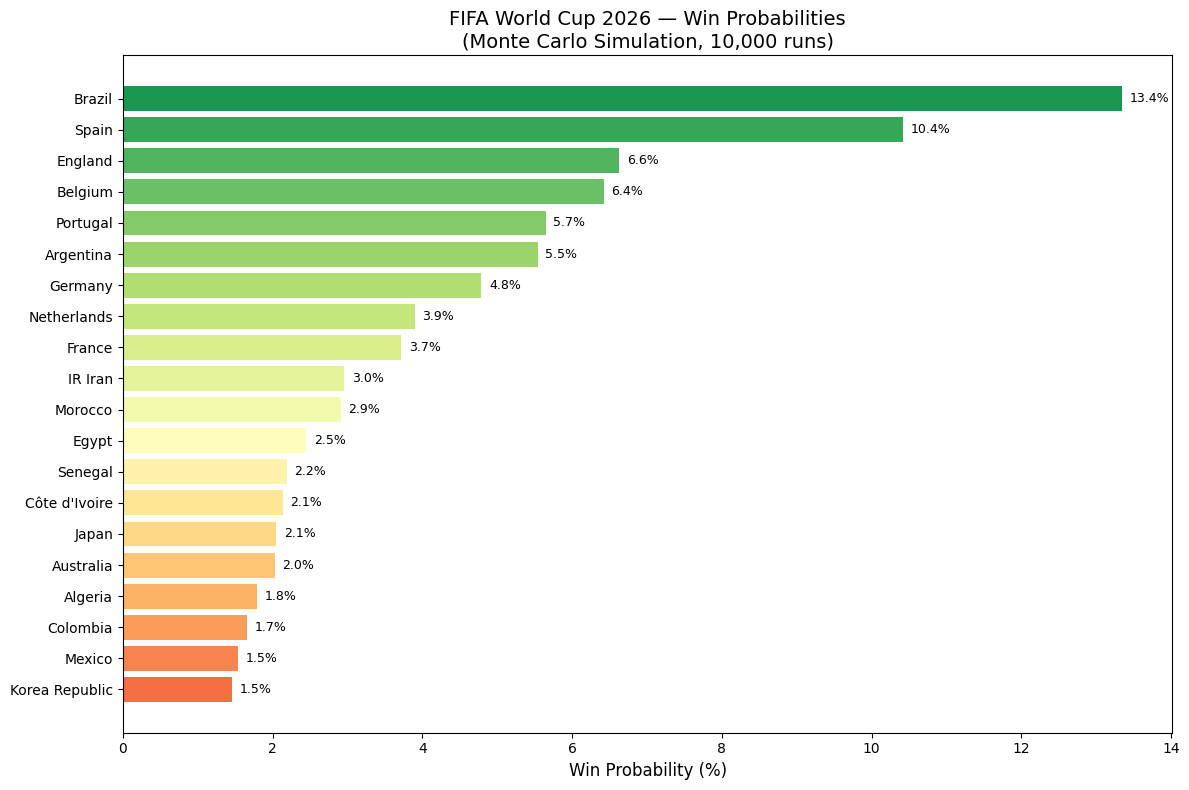

In [ ]:
# Build results dataframe
results_df = pd.DataFrame([
    {"team": team, "wins": count, "win_pct": count/N_SIMULATIONS*100}
    for team, count in win_counts_final.most_common()
]).head(20)

plt.figure(figsize=(12, 8))
bars = plt.barh(results_df["team"][::-1], results_df["win_pct"][::-1],
                color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, 20)))
plt.xlabel("Win Probability (%)", fontsize=12)
plt.title("FIFA World Cup 2026 — Win Probabilities\n(Monte Carlo Simulation, 10,000 runs)",
          fontsize=14)

# Add value labels
for bar, val in zip(bars, results_df["win_pct"][::-1]):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("wc2026_win_probabilities.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Track group stage finishes across simulations
from collections import defaultdict

N_SIMULATIONS = 10_000
win_counts_final = Counter()
group_finish = defaultdict(lambda: {1: 0, 2: 0, 3: 0, 4: 0})

print("Running 10,000 simulations tracking group finishes...")
start = time.time()

for i in range(N_SIMULATIONS):
    if (i+1) % 2000 == 0:
        print(f"  {i+1} / {N_SIMULATIONS} complete...")

    s, bt = simulate_group_stage_fast(groups, team_ratings_final, avg_goals)
    win_counts_final[simulate_knockout_fast(s, bt, team_ratings_final, avg_goals)] += 1

    # Record group finish positions
    for group_name, standings in s.items():
        for rank, (team, pts, gd, gf) in enumerate(standings, 1):
            group_finish[team][rank] += 1

elapsed = time.time() - start
print(f"\nDone in {elapsed:.1f}s")

Running 10,000 simulations tracking group finishes...
  2000 / 10000 complete...
  4000 / 10000 complete...
  6000 / 10000 complete...
  8000 / 10000 complete...
  10000 / 10000 complete...

Done in 99.4s


In [ ]:
# Build qualification probability dataframe
finish_data = []

for group_name, teams in groups.items():
    for team in teams:
        finishes = group_finish[team]
        total = sum(finishes.values())
        finish_data.append({
            "group": group_name,
            "team": team,
            "1st": finishes[1] / total * 100,
            "2nd": finishes[2] / total * 100,
            "3rd": finishes[3] / total * 100,
            "4th": finishes[4] / total * 100,
            "qualify": (finishes[1] + finishes[2]) / total * 100  # top 2 auto qualify
        })

finish_df = pd.DataFrame(finish_data).sort_values(["group", "1st"], ascending=[True, False])
print(finish_df[["group","team","1st","2nd","3rd","4th","qualify"]].to_string())

   group                    team    1st    2nd    3rd    4th  qualify
0      A                  Mexico  31.08  27.08  23.23  18.61    58.16
1      A            South Africa  27.19  26.68  25.58  20.55    53.87
2      A          Korea Republic  26.84  26.54  24.90  21.72    53.38
3      A                 Czechia  14.89  19.70  26.29  39.12    34.59
7      B             Switzerland  30.94  27.11  23.47  18.48    58.05
4      B                  Canada  30.82  27.33  24.17  17.68    58.15
6      B                   Qatar  22.27  24.35  25.78  27.60    46.62
5      B  Bosnia and Herzegovina  15.97  21.21  26.58  36.24    37.18
8      C                  Brazil  60.70  26.96   9.43   2.91    87.66
9      C                 Morocco  28.23  41.15  21.16   9.46    69.38
11     C                Scotland   5.60  15.97  33.87  44.56    21.57
10     C                   Haiti   5.47  15.92  35.54  43.07    21.39
14     D               Australia  37.46  29.33  21.19  12.02    66.79
12     D            

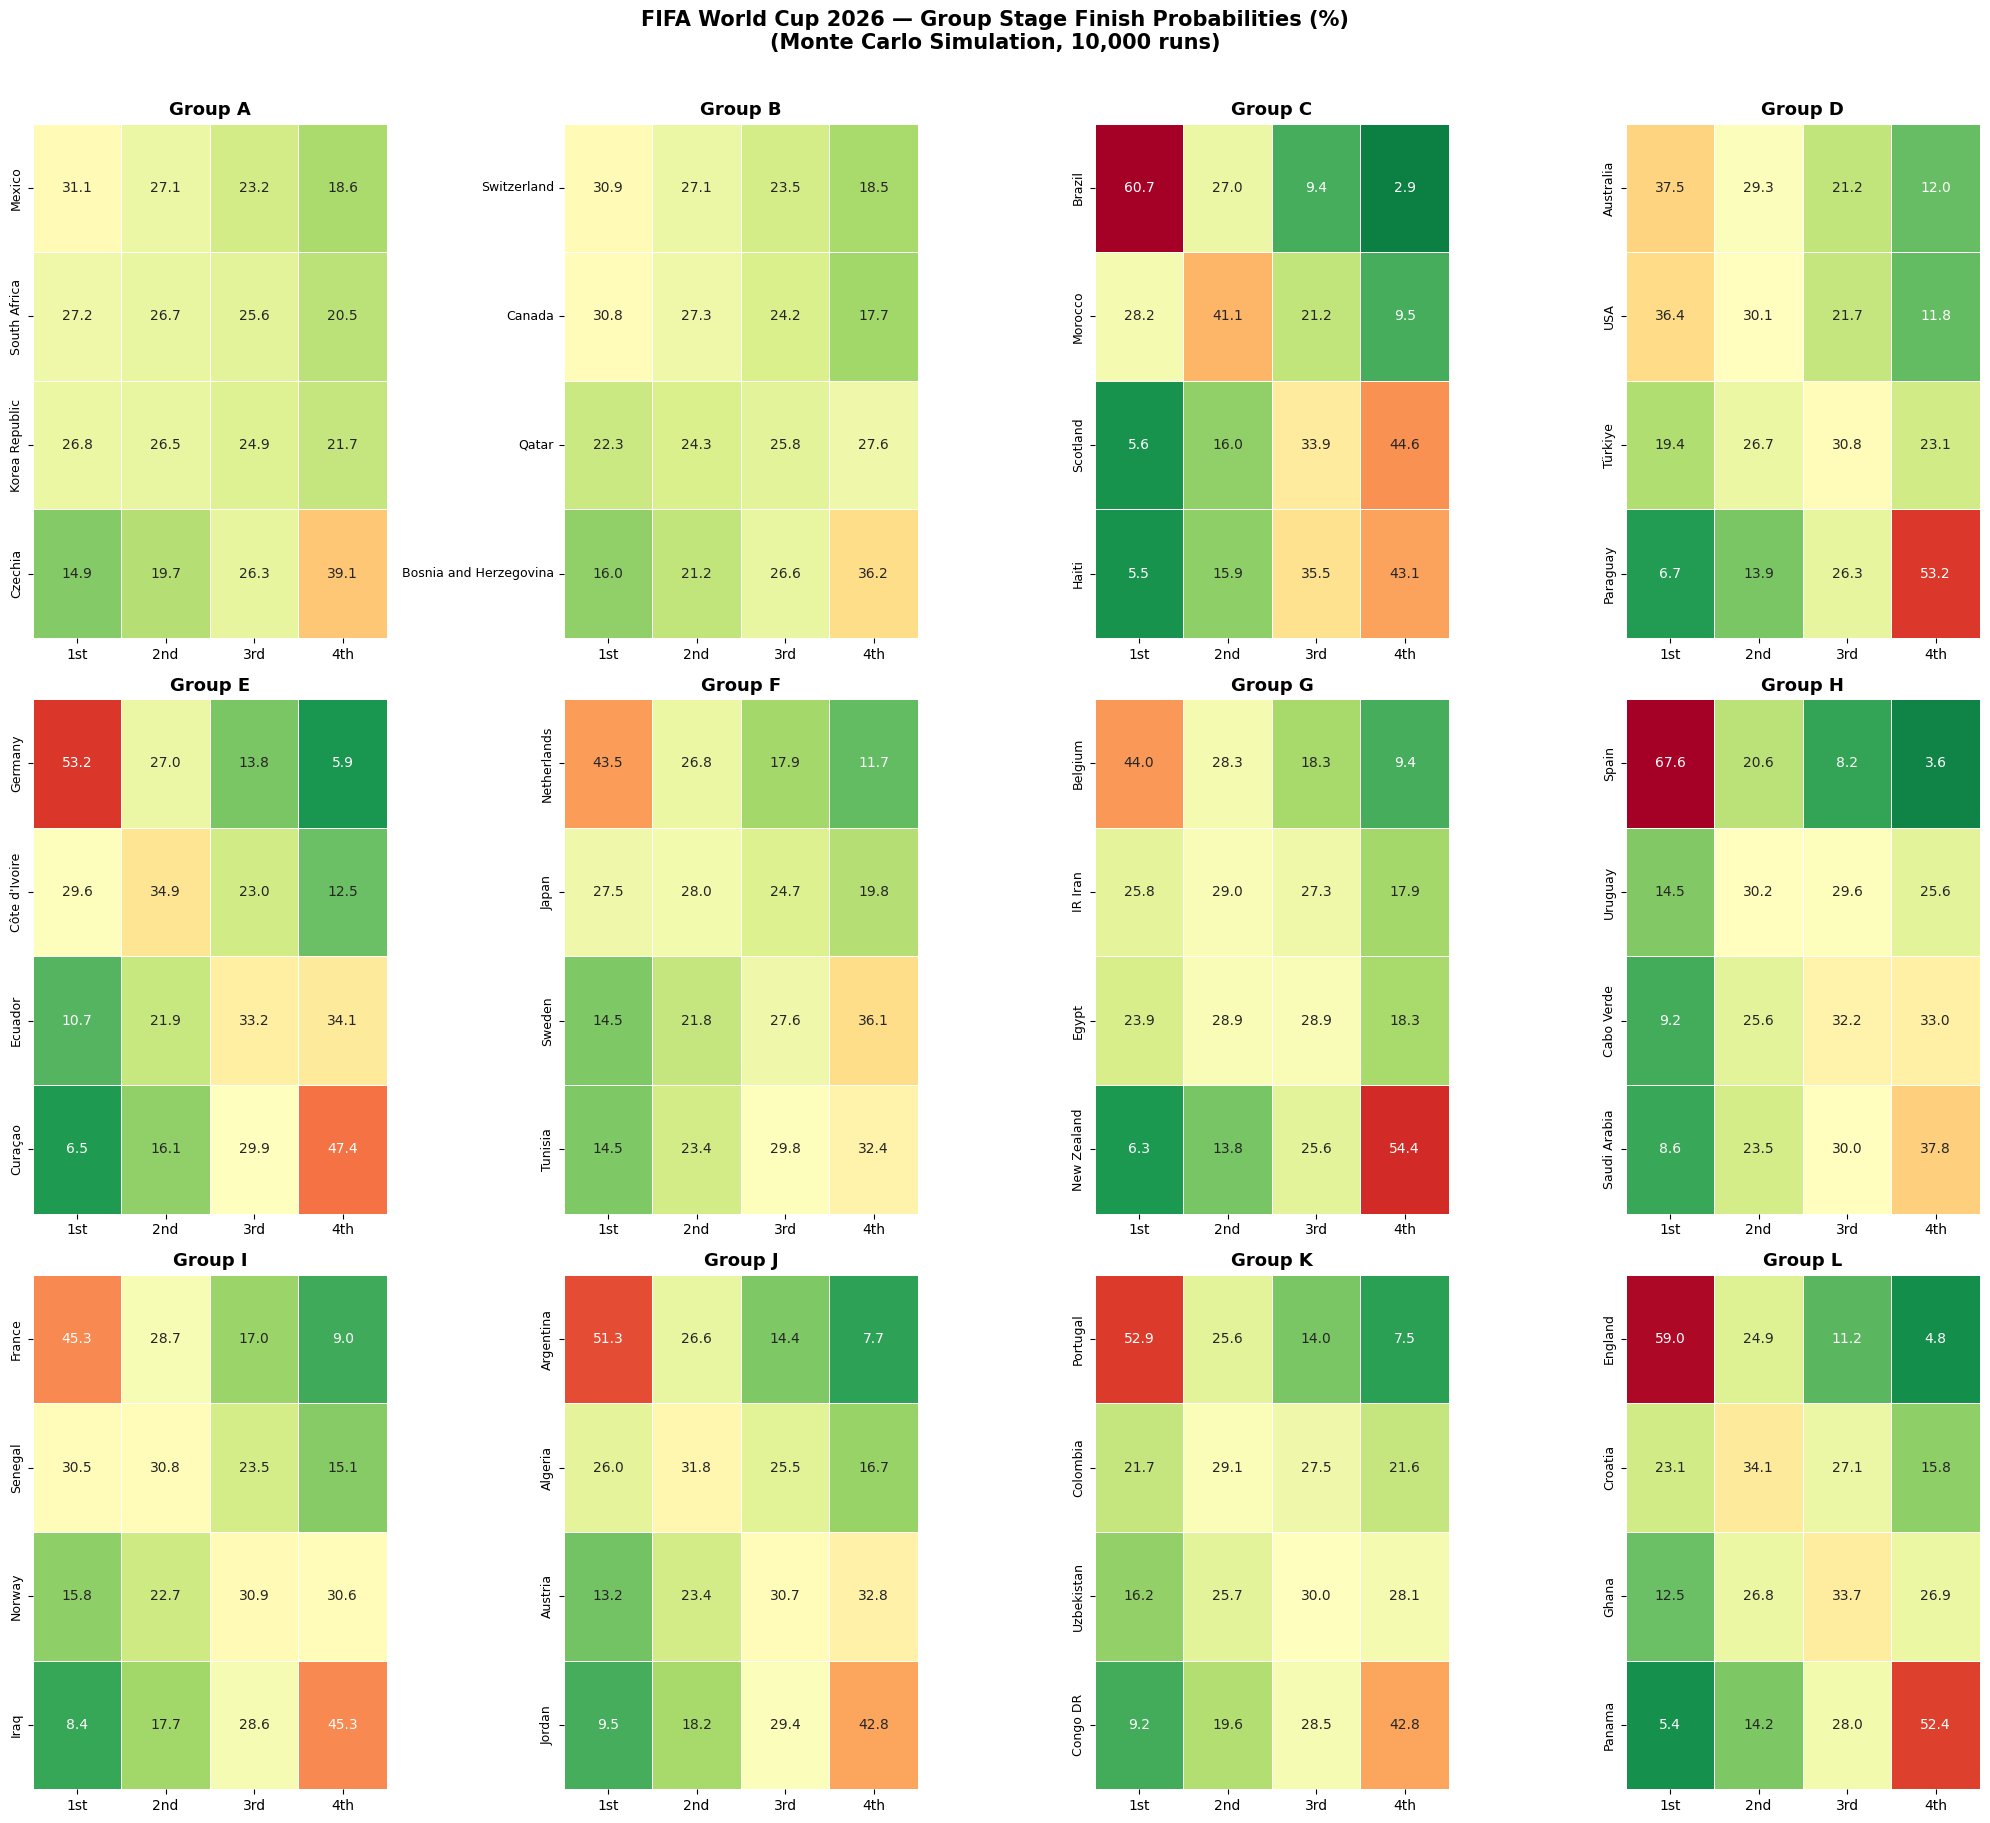

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 18))
axes = axes.flatten()

col_labels = ["1st", "2nd", "3rd", "4th"]

for idx, (group_name, teams) in enumerate(groups.items()):
    ax = axes[idx]
    group_df = finish_df[finish_df["group"] == group_name].set_index("team")[col_labels]

    sns.heatmap(
        group_df,
        annot=True,
        fmt=".1f",
        cmap="RdYlGn_r",
        vmin=0, vmax=60,
        ax=ax,
        cbar=False,
        linewidths=0.5
    )
    ax.set_title(f"Group {group_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle(
    "FIFA World Cup 2026 — Group Stage Finish Probabilities (%)\n(Monte Carlo Simulation, 10,000 runs)",
    fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("wc2026_group_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import shutil

# Save final outputs
results_final_df = pd.DataFrame([
    {"team": team, "wins": count, "win_pct": round(count/N_SIMULATIONS*100, 2)}
    for team, count in win_counts_final.most_common()
])
results_final_df.to_csv("wc2026_win_probabilities.csv", index=False)
finish_df.to_csv("wc2026_group_probabilities.csv", index=False)
team_ratings_final.to_csv("team_ratings_final.csv", index=False)

# Copy all Phase 4 outputs to Drive
files = [
    "wc2026_win_probabilities.csv",
    "wc2026_group_probabilities.csv",
    "team_ratings_final.csv",
    "wc2026_win_probabilities.png",
    "wc2026_group_heatmap.png",
]

for f in files:
    shutil.copy(f, f"/content/drive/MyDrive/FIFA_WC_2026/{f}")
    print(f"✓ Saved {f}")

print("\nAll Phase 4 outputs saved to Drive")

✓ Saved wc2026_win_probabilities.csv
✓ Saved wc2026_group_probabilities.csv
✓ Saved team_ratings_final.csv
✓ Saved wc2026_win_probabilities.png
✓ Saved wc2026_group_heatmap.png

All Phase 4 outputs saved to Drive


Full Project Summary ✓
Phase 1 — Data Cleaning & Feature Engineering

30,511 matches cleaned and filtered to modern era
53 features engineered including FIFA rankings, rolling form, H2H deltas, and tournament context
204 FIFA nations with attack/defense ratings

Phase 2 — Match Outcome Classifier

Logistic Regression: 54.7% accuracy — selected for probability outputs
Random Forest: 58.6% accuracy — used for feature importance analysis
Key finding: FIFA ranking gap and 10-game form deltas are strongest predictors

Phase 3 — Poisson Score Prediction

59.0% accuracy on 4,016 post-2022 matches
Generates full scoreline probability matrix for any matchup
Brazil vs Argentina: 1-1 most likely at 13.1%

Phase 4 — Monte Carlo Tournament Simulator

10,000 simulations of the full WC 2026 bracket
Confederation strength adjustment applied to correct regional inflation
Brazil 13.4% favourites, Spain 10.4%, England 6.6%
All 48 teams won at least once across simulations